# Denoising neural network notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf


I0000 00:00:1778770653.191469  690180 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778770653.237179  690180 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778770654.969406  690180 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Limita TF a usare massimo 8GB (8192 MB)
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=15*1024)]
        )

    except RuntimeError as e:
        print(e)

In [3]:
import keras
from keras.models import Model

In [4]:
from keras import layers

# Basic Convolutional neural networks for denoising

In this notebook you will familiarize with the basic structure in keras of a denoising neural network.

I have provided you two vectors of data, one noisy, one noiseless, for supervised training

In [5]:
#dataNoisy = np.load('/tf/mine/BRATS/dataNoise05Train_192.npy')
dataV = np.load('../BRATS/dataTrueTrain_192.npy')


In [6]:
dataV = np.expand_dims(dataV,axis=-1)
dataV = np.transpose(dataV,(2,0,1,3))
dataRed = dataV[:1500,:,:,:]
dataRedNoise = dataRed+np.random.normal(0,0.05,dataRed.shape)

yTest = np.load('../BRATS/dataTrueTest_192.npy')
yTest = np.expand_dims(yTest,axis=-1)
yTest = np.transpose(yTest,(2,0,1,3))
yTestNoise = yTest+np.random.normal(0,0.05,yTest.shape)

## Define the neural network

Here, build a very basic neural network that downsamples only once and uses 16 filters in the first layer, 32 in the second and 64 in the "bridge".

This way you can run a successfull training just on the CPU

In [7]:
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

def unet_4_levels(input_size=(128, 128, 1)):
    inputs = Input(input_size)
    
    # Downsampling path
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs) #192 rec field 3
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1) # rec field 5
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1) #96 # recfield 10x10
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2) # rec field 14x14
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2) #48 # rec field 24
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3) # rec field 32
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3) #24 # rec field 48
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv4) # rec field 64
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4) # rec field 80

    # Upsampling path
    up3 = UpSampling2D(size=(2, 2))(conv4)
    up3 = concatenate([up3, conv3])
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(up3)
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv5)

    up2 = UpSampling2D(size=(2, 2))(conv5)
    up2 = concatenate([up2, conv2])
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(up2)
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv6)

    up1 = UpSampling2D(size=(2, 2))(conv6)
    up1 = concatenate([up1, conv1])
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(up1)
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv7)

    outputs = Conv2D(1, (1, 1))(conv7)
    
    model = Model(inputs, outputs)
    return model


In [7]:
myModel = unet_4_levels((192,192,1))

I0000 00:00:1778670264.056215  114440 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15360 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


## Prepare for the training
Define the optimizer and the loss. You will need to choose the learning rate as a hyperparameter (fur such a shallow network 1e-2 /5e-3 should be good)

In [9]:
from keras.optimizers import Adam
optim= Adam(learning_rate=1e-5)
myModel.compile(optimizer=optim,loss=tf.keras.losses.MeanSquaredError(),metrics=['mae'])

Gradually increase the learning rate (manual warmup)

In [10]:
fitHist = myModel.fit(dataRedNoise,dataRed,epochs=1,validation_data=(yTestNoise,yTest),batch_size=32)

I0000 00:00:1778670272.549665  114609 service.cc:153] XLA service 0x7f06f4043810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778670272.549710  114609 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778670272.600998  114609 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778670272.949213  114609 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778670284.151835  114609 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 407ms/step - loss: 0.2325 - mae: 0.2526 - val_loss: 0.1697 - val_mae: 0.2235


In [12]:
myModel.optimizer.learning_rate.assign(0.001)
fitHist = myModel.fit(dataRedNoise,dataRed,epochs=100,validation_data=(yTestNoise,yTest),batch_size=32)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0045 - mae: 0.0265 - val_loss: 0.0013 - val_mae: 0.0150
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 8.2196e-04 - mae: 0.0132 - val_loss: 5.7727e-04 - val_mae: 0.0118
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 4.9140e-04 - mae: 0.0111 - val_loss: 4.4514e-04 - val_mae: 0.0102
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 4.2504e-04 - mae: 0.0100 - val_loss: 4.1229e-04 - val_mae: 0.0098
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 4.0647e-04 - mae: 0.0097 - val_loss: 3.9415e-04 - val_mae: 0.0096
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 3.8428e-04 - mae: 0.0093 - val_loss: 3.7883e-04 - val_mae: 0.0092
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 3.6966e-04 - mae: 0.0091 - val_loss: 3.6538e-04 - val_mae: 0.0091
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 3.9461e-04 - mae: 0.0094 - val_loss: 5.0186e-04 - val_mae: 0.0109

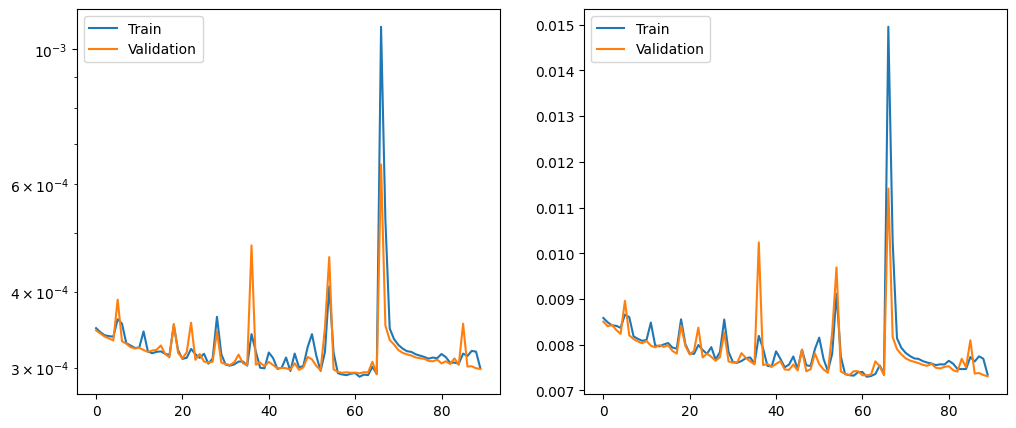

In [14]:
plt.figure(figsize=(12,5))
startEp = 10
plt.subplot(121)
plt.plot(fitHist.history['loss'][startEp:])
plt.plot(fitHist.history['val_loss'][startEp:])
plt.yscale('log')
plt.legend(['Train','Validation'])
plt.subplot(122)
plt.plot(fitHist.history['mae'][startEp:])
plt.plot(fitHist.history['val_mae'][startEp:])
plt.legend(['Train','Validation'])

### 2nd training with lower LR

In [17]:
myModel.optimizer.learning_rate.assign(0.0001)
fitHist = myModel.fit(dataRedNoise,dataRed,epochs=20,validation_data=(yTestNoise,yTest),batch_size=32)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 2.9619e-04 - mae: 0.0073 - val_loss: 2.9655e-04 - val_mae: 0.0073
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 2.9595e-04 - mae: 0.0073 - val_loss: 2.9688e-04 - val_mae: 0.0073
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 2.9588e-04 - mae: 0.0073 - val_loss: 2.9638e-04 - val_mae: 0.0073
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 2.9586e-04 - mae: 0.0073 - val_loss: 2.9643e-04 - val_mae: 0.0073
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 2.9566e-04 - mae: 0.0073 - val_loss: 2.9635e-04 - val_mae: 0.0073
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 2.9558e-04 - mae: 0.0073 - val_loss: 2.9583e-04 - val_mae: 0.0073
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 2.9549e-04 - mae: 0.0073 - val_loss: 2.9585e-04 - val_mae: 0.0073
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 2.9544e-04 - mae: 0.0073 - val_loss: 2.9641e-04 - val_mae: 0.0073

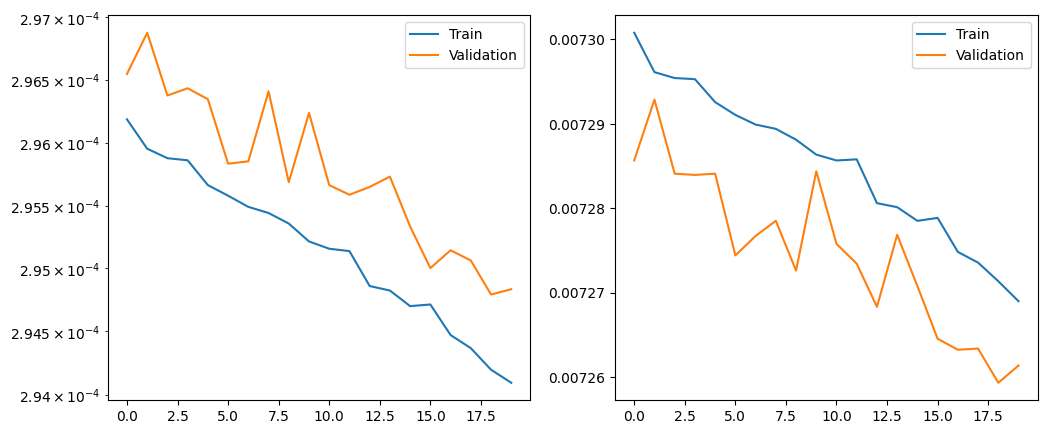

In [18]:
plt.figure(figsize=(12,5))
startEp = 0
plt.subplot(121)
plt.plot(fitHist.history['loss'][startEp:])
plt.plot(fitHist.history['val_loss'][startEp:])
plt.yscale('log')
plt.legend(['Train','Validation'])
plt.subplot(122)
plt.plot(fitHist.history['mae'][startEp:])
plt.plot(fitHist.history['val_mae'][startEp:])
plt.legend(['Train','Validation'])

### Load ADNI data for testing

In [24]:
data_test = np.load('/mnt/d/dati_corso/BRATS/adni_test_192.npy')
data_test = data_test[:,:,:,None]



### Rescale the data
If the data are not in the same range, the fitting won't work!

In [28]:
for i in range(data_test.shape[0]):
    iT = data_test[i,:,:,:]
    lT = np.percentile(iT,0.5)
    sV = iT[iT>lT].mean()
    if (sV<1e-5) | (np.isnan(sV)):
        sV=1
    iT/= sV
    data_test[i,:,:,:]=iT

/tmp/ipykernel_690180/1978377522.py:4: RuntimeWarning: Mean of empty slice.
  sV = iT[iT>lT].mean()
/home/luca/tf/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [21]:
noisy_test = data_test+np.random.normal(0,0.05,data_test.shape)

In [22]:
myModel.evaluate(noisy_test,data_test,batch_size=64)

52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 3.5073e-04 - mae: 0.0093


[0.0003507276705931872, 0.00926945824176073]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


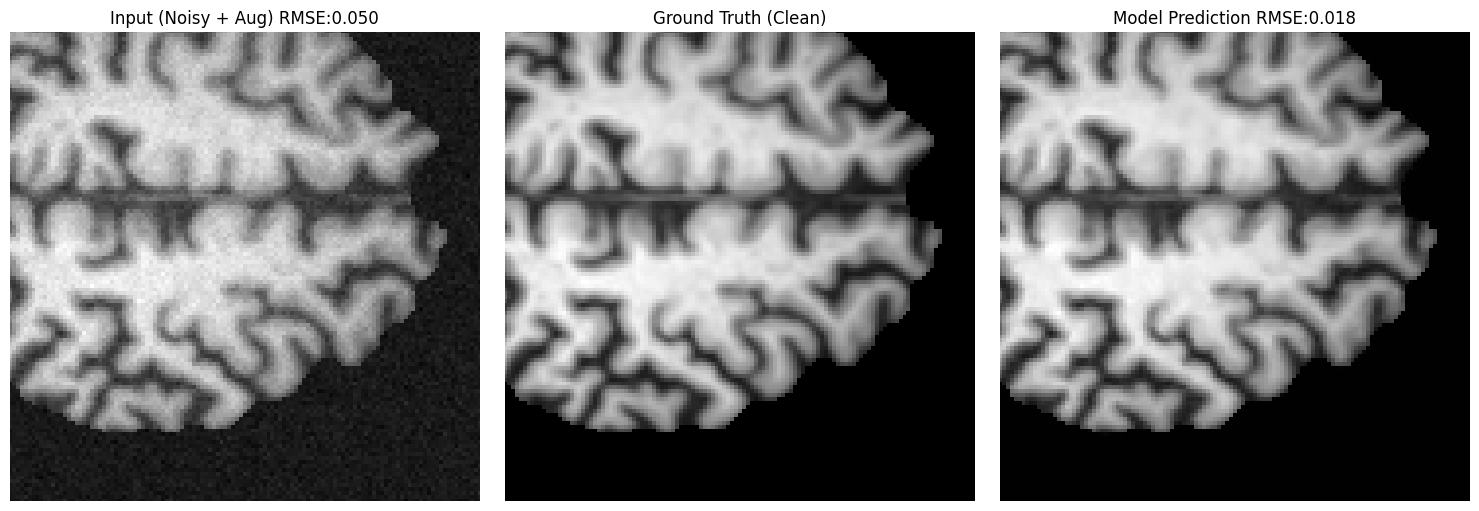

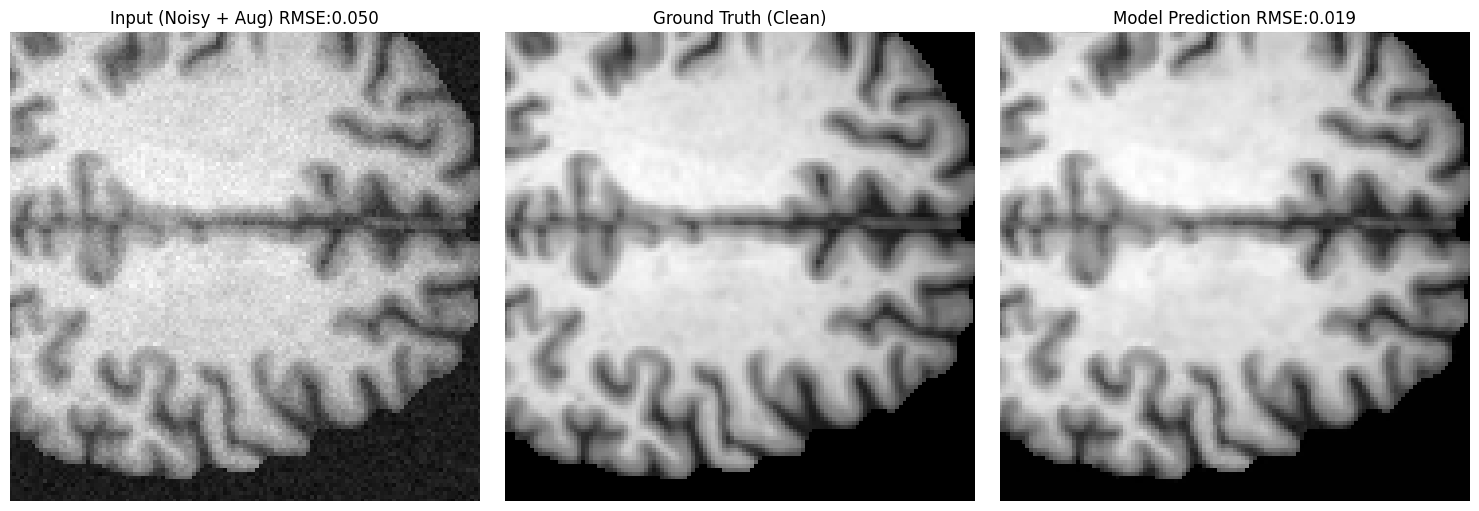

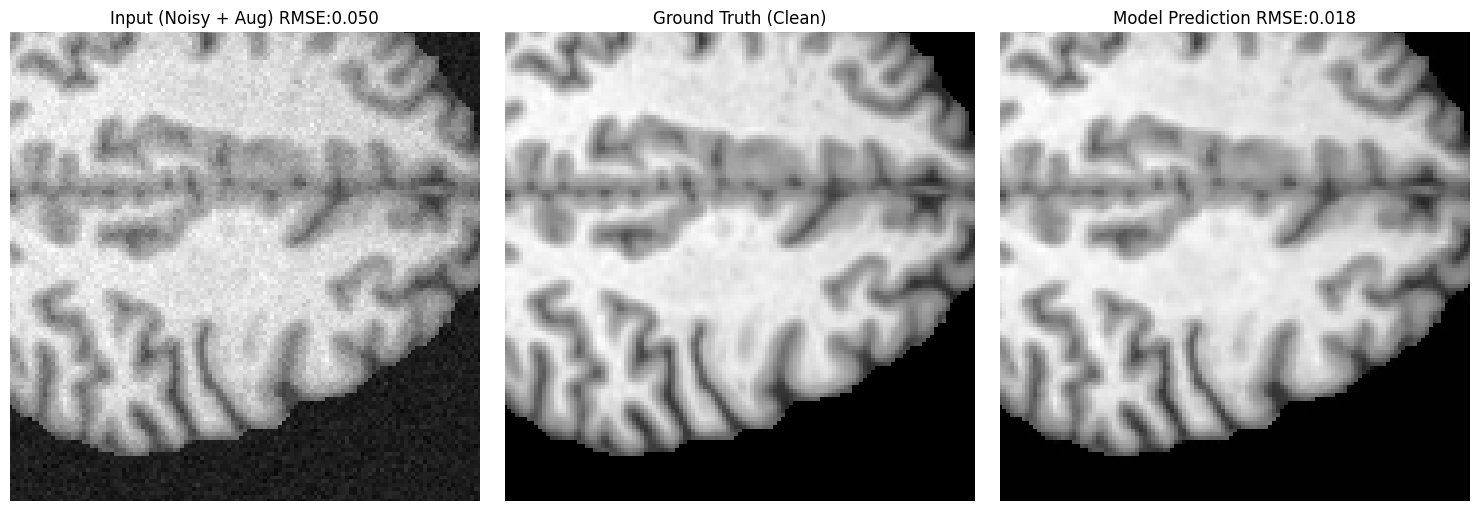

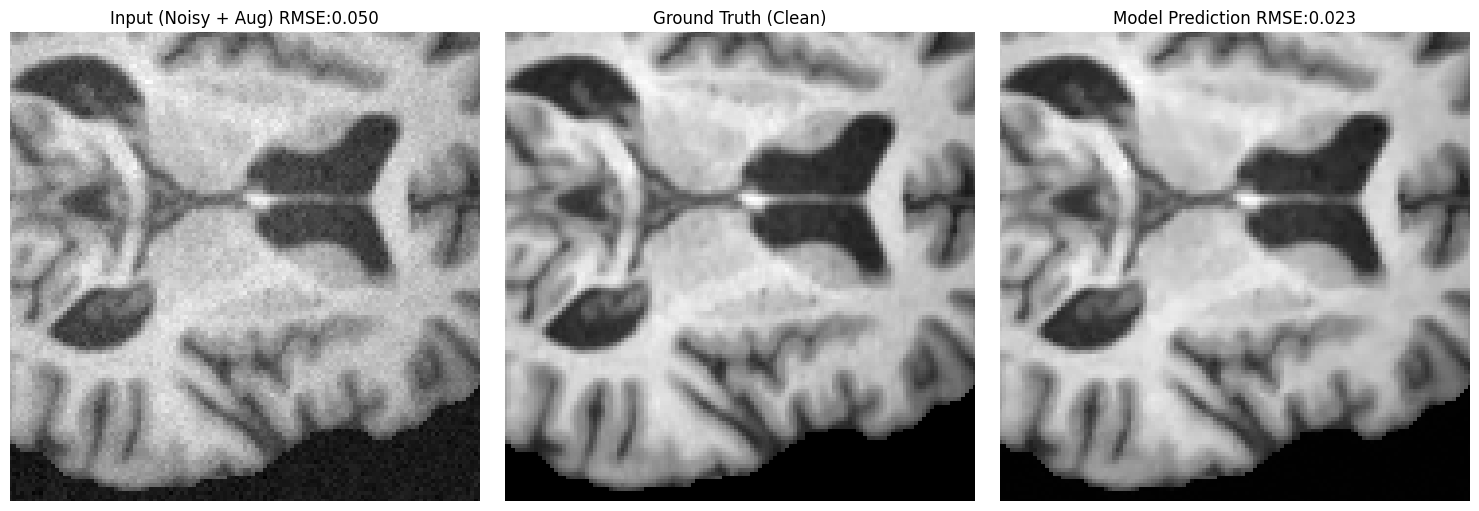

In [23]:
idx = np.random.randint(0,data_test.shape[0],4)
inpB = noisy_test[idx,:,:,:]
outTrue = data_test[idx,:,:,:]
    # Facciamo la predizione sul batch
    # .numpy() serve per convertire il tensore in un array visualizzabile
predicted_batch = myModel.predict(inpB)
    
    # Scegliamo la prima immagine del batch per la visualizzazione
for bIdx in range(4):
        
    plt.figure(figsize=(15, 5))
    iNA = inpB[bIdx,:,:,0]
    iClean = outTrue[bIdx,:,:,0]
    iPred = predicted_batch.squeeze()
    iPred = iPred[bIdx,:,:]
    rmseInp = np.sqrt(np.mean((iNA-iClean)**2))
    rmseOut = np.sqrt(np.mean((iPred-iClean)**2))
    # 1. Input Rumoroso (Quello che la rete "vede")
    plt.subplot(1, 3, 1)
    plt.title(f"Input (Noisy + Aug) RMSE:{rmseInp:.3f}")
    plt.imshow(iNA, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)
    plt.axis('off')
    
    # 2. Target Pulito (Quello che la rete "dovrebbe" restituire)
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth (Clean)")
    plt.imshow(iClean, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    # 3. Output del Modello (Quello che la rete "ha ricostruito")
    plt.subplot(1, 3, 3)
    plt.title(f"Model Prediction RMSE:{rmseOut:.3f}")
    plt.imshow(iPred, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

### Validate this model vs noise level

In [24]:
noiseLevels = [0.005,0.01,0.025,0.05,0.1,0.2]
mseValOr = np.zeros((len(noiseLevels),))
maeValOr = np.zeros((len(noiseLevels),))
mseTestOr = np.zeros((len(noiseLevels),))
maeTestOr = np.zeros((len(noiseLevels),))
for idx,sigmaNoise in enumerate(noiseLevels):
    yTestNoise = yTest+np.random.normal(0,sigmaNoise,yTest.shape)
    a,b = myModel.evaluate(yTestNoise,yTest,batch_size=64)
    mseValOr[idx] = a
    maeValOr[idx] = b
    noisy_test = data_test+np.random.normal(0,sigmaNoise,data_test.shape)
    a,b = myModel.evaluate(noisy_test,data_test,batch_size=64)
    mseTestOr[idx]=a
    maeTestOr[idx]=b



74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 1.5552e-04 - mae: 0.0052
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.2532e-04 - mae: 0.0054
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.5846e-04 - mae: 0.0052
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.3055e-04 - mae: 0.0056
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.8054e-04 - mae: 0.0056
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.6929e-04 - mae: 0.0064
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 2.9489e-04 - mae: 0.0073
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.5059e-04 - mae: 0.0093
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0017 - mae: 0.0191
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0022 - mae: 0.0244
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0127 - mae: 0.0580
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0152 - mae: 0.0695


Text(0.5, 1.0, 'MAE')

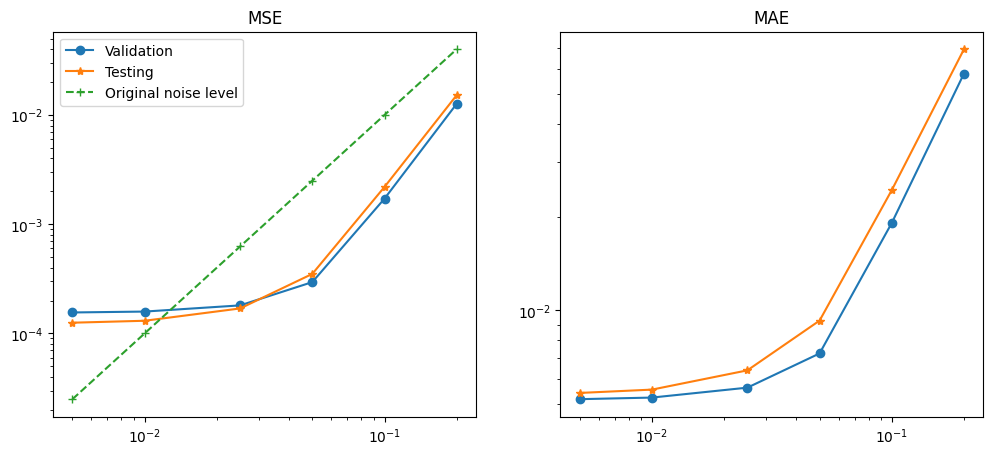

In [47]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(noiseLevels,mseValOr,'o-',label='Validation')
plt.plot(noiseLevels,mseTestOr,'*-',label='Testing')
plt.plot(noiseLevels,np.array(noiseLevels)**2,'+--',label='Original noise level')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.title('MSE')
plt.subplot(122)
plt.plot(noiseLevels,maeValOr,'o-')
plt.plot(noiseLevels,maeTestOr,'*-')
plt.yscale('log')
plt.xscale('log')
plt.title('MAE')

# Augmentation


### Basic Keras augmentation

In [93]:
# Define augmentation layers
data_augmentation = keras.Sequential([
keras.layers.GaussianNoise(stddev=.04),
keras.layers.RandomFlip("vertical"),
keras.layers.RandomRotation(0.03),
keras.layers.RandomZoom(0.05),
keras.layers.RandomGaussianBlur(
    factor=.7,
    kernel_size=5,
    sigma=1,
    value_range=(0,2)
)
])

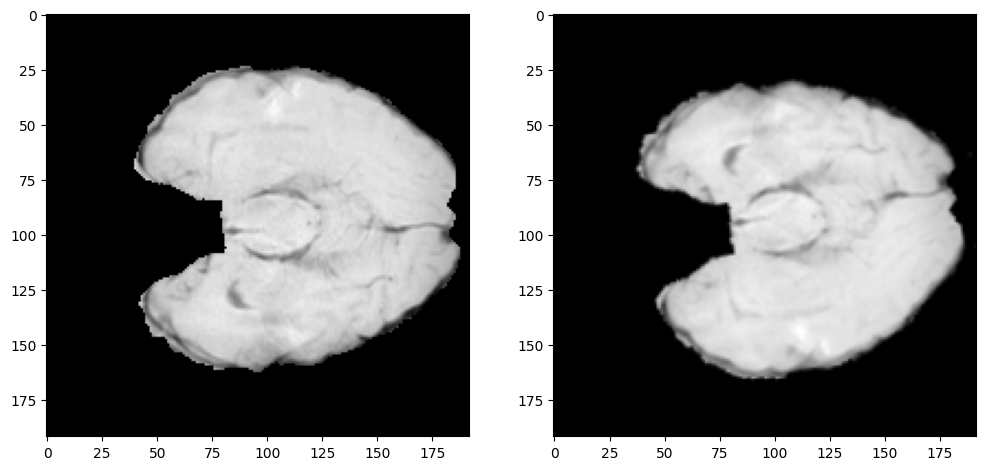

In [108]:
augImm =data_augmentation(dataV[0:32,:,:,:])
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(dataV[20,:,:,:],cmap='gray')
plt.subplot(122)
plt.imshow(augImm[20,:,:,:],cmap='gray')

### Augmentation for denoising

In Keras you're not able to apply the same augmentation to input and output, which is needed for denoising (and segmentation)

We'll need to do it manually

In [26]:
from keras import layers

def add_noise_layer(x):
    # Questa funzione ora viene eseguita nel contesto giusto
    noise_factor = tf.random.uniform([], 0.0, 0.14)
    noise = noise_factor * tf.random.normal(shape=tf.shape(x))
    return (x + noise)

def apply_intensity_aug(x):

    gain = tf.random.normal(mean=1,stddev=.1,shape=[])
    x = x * gain
    
    gamma = tf.random.normal(mean=1,stddev=.1, shape=[])
    x = tf.pow(x, gamma)
    return x

def get_augmentation_model(img_size=(256, 256)):
    
    clean_input = layers.Input(shape=(*img_size, 1))
    clean_input = layers.Lambda(add_noise_layer)(clean_input)
    clean_input = layers.RandomGaussianBlur(
            factor=.7,
            kernel_size=5,
            sigma=1,
            value_range=(0,2)
        ) (clean_input)
    
    

    target_input = layers.Input(shape=(*img_size, 1))

    # 1. Concatenazione
    combined = layers.Concatenate(axis=-1)([clean_input, target_input])
    

    # 2. Trasformazioni spaziali (usano layer Keras nativi, quindi ok)
    x = layers.RandomFlip("vertical")(combined)
    x = layers.Lambda(apply_intensity_aug)(x)
    x = layers.RandomRotation(0.02)(x)
   # x = layers.RandomTranslation(2,2)(x)
    x = layers.RandomZoom(0.05)(x)

    # 3. Split
    aug_input = layers.Lambda(lambda t: t[:, :, :, :1])(x)
    aug_target = layers.Lambda(lambda t: t[:, :, :, 1:])(x)

    # 4. Rumore (avvolto in Lambda per evitare il ValueError)
    noisy_input = layers.Lambda(add_noise_layer)(aug_input)

    return keras.Model(inputs=[clean_input, target_input], outputs=[noisy_input, aug_target])

augModel = get_augmentation_model(img_size=dataV.shape[1:3])


In [ ]:
@tf.function # Needed because apparently tf explodes somehow...
def fast_augment(batch_x):
   
    return augModel([batch_x, batch_x], training=True)

### Show the effect of the augmentation routine combined

(np.float64(-0.5), np.float64(191.5), np.float64(191.5), np.float64(-0.5))

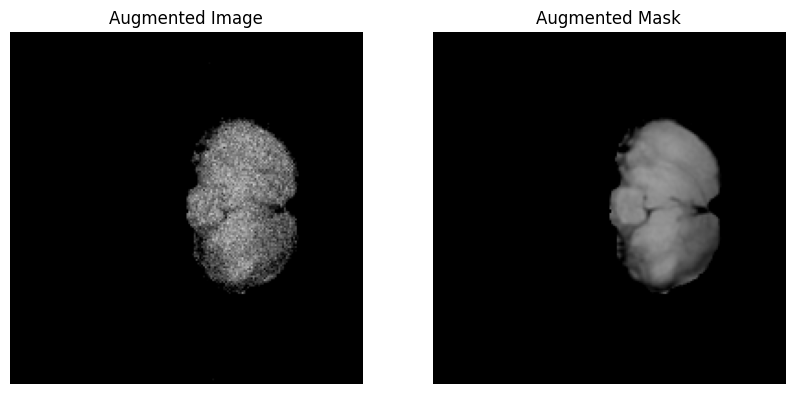

In [120]:
aug_img, aug_mask = fast_augment([dataV[:32,:,:,:]])
# 4. Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Augmented Image")
plt.imshow(aug_img[3,:,:,0],cmap='gray',vmin=.4,vmax=1.5)
plt.axis('off')
# plt.xlim(20,170)
# plt.ylim(100,20)

plt.subplot(1, 2, 2)
plt.title("Augmented Mask")
plt.imshow(aug_mask[3,:,:,0].numpy().squeeze(), cmap='gray',vmin=.4,vmax=1.5)
plt.axis('off')
# plt.xlim(20,100)
# plt.ylim(100,20)


Create Tensorflow generators to feed the data while applying `.map(fast_augment)` to compute augmentation online

In [29]:
train_ds = tf.data.Dataset.from_tensor_slices(dataRed)
test_ds = tf.data.Dataset.from_tensor_slices(yTest)

train_ds = (train_ds
            .shuffle(buffer_size=1000) # Mischia le immagini
            .batch(32)                # Crea i batch
            .map(fast_augment, num_parallel_calls=tf.data.AUTOTUNE) # Applica l'augmentation
            .prefetch(tf.data.AUTOTUNE)) # Carica il batch successivo mentre la GPU lavora
test_ds = (test_ds.batch(32).map(fast_augment,num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE))

In [30]:
fitHist = myModel.fit(train_ds,validation_data=test_ds,epochs=100)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 6.5444e-04 - mae: 0.0108 - val_loss: 5.0465e-04 - val_mae: 0.0094
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 4.8273e-04 - mae: 0.0093 - val_loss: 4.8362e-04 - val_mae: 0.0092
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 4.0412e-04 - mae: 0.0083 - val_loss: 5.1742e-04 - val_mae: 0.0095
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 4.6602e-04 - mae: 0.0089 - val_loss: 5.1360e-04 - val_mae: 0.0094
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 4.4581e-04 - mae: 0.0088 - val_loss: 4.8162e-04 - val_mae: 0.0092
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 4.3974e-04 - mae: 0.0088 - val_loss: 5.1318e-04 - val_mae: 0.0094
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 4.9304e-04 - mae: 0.0096 - val_loss: 4.9845e-04 - val_mae: 0.0093
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 4.2713e-04 - mae: 0.0087 - val_loss: 4.9044e-04 - 

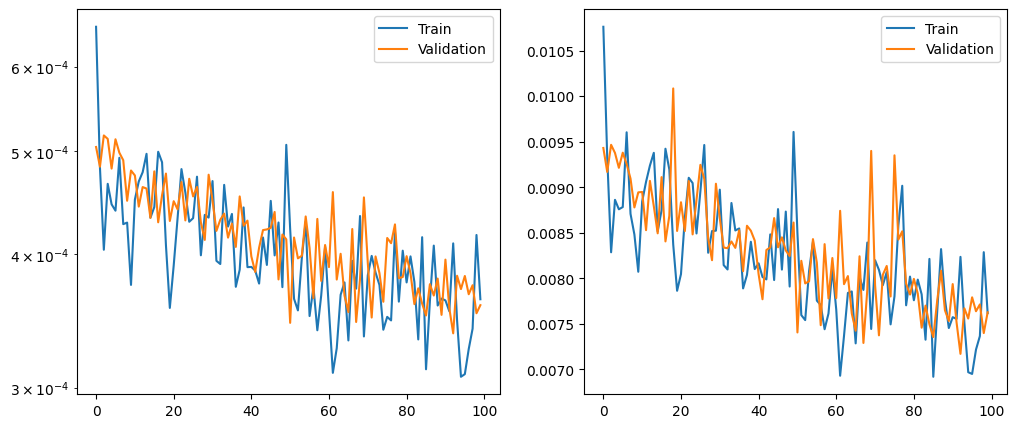

In [33]:
plt.figure(figsize=(12,5))
startEp = 0
plt.subplot(121)
plt.plot(fitHist.history['loss'][startEp:])
plt.plot(fitHist.history['val_loss'][startEp:])
plt.yscale('log')
plt.legend(['Train','Validation'])
plt.subplot(122)
plt.plot(fitHist.history['mae'][startEp:])
plt.plot(fitHist.history['val_mae'][startEp:])
plt.legend(['Train','Validation'])


In [32]:
noiseLevels = [0.005,0.01,0.025,0.05,0.1,0.2]
mseVal = np.zeros((len(noiseLevels),))
maeVal = np.zeros((len(noiseLevels),))
mseTest = np.zeros((len(noiseLevels),))
maeTest = np.zeros((len(noiseLevels),))
for idx,sigmaNoise in enumerate(noiseLevels):
    yTestNoise = yTest+np.random.normal(0,sigmaNoise,yTest.shape)
    a,b = myModel.evaluate(yTestNoise,yTest,batch_size=64)
    mseVal[idx] = a
    maeVal[idx] = b
    noisy_test = data_test+np.random.normal(0,sigmaNoise,data_test.shape)
    a,b = myModel.evaluate(noisy_test,data_test,batch_size=64)
    mseTest[idx]=a
    maeTest[idx]=b


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.8468e-04 - mae: 0.0053
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 8.6970e-05 - mae: 0.0043
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.9173e-04 - mae: 0.0054
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 9.6539e-05 - mae: 0.0046
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 2.4044e-04 - mae: 0.0063
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.6323e-04 - mae: 0.0062
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.9805e-04 - mae: 0.0082
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.6882e-04 - mae: 0.0095
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 8.5375e-04 - mae: 0.0122
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 9.3193e-04 - mae: 0.0152
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0022 - mae: 0.0207
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0027 - mae: 0.0267


Text(0.5, 1.0, 'MAE')

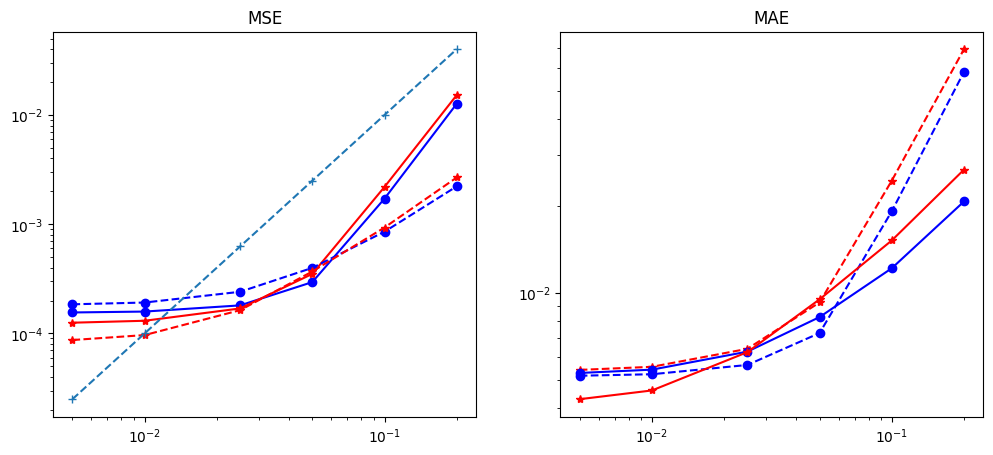

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(noiseLevels,mseValOr,'bo-')
plt.plot(noiseLevels,mseTestOr,'r*-')
plt.plot(noiseLevels,mseVal,'bo--')
plt.plot(noiseLevels,mseTest,'r*--')
plt.plot(noiseLevels,np.array(noiseLevels)**2,'+--')
plt.yscale('log')
plt.xscale('log')
plt.title('MSE')
plt.subplot(122)
plt.plot(noiseLevels,maeValOr,'bo--')
plt.plot(noiseLevels,maeTestOr,'r*--')
plt.plot(noiseLevels,maeVal,'bo-')
plt.plot(noiseLevels,maeTest,'r*-')
plt.yscale('log')
plt.xscale('log')
plt.title('MAE')

### Results comment
After being trained on many different noise levels we can see the network generalizes too very different noise levels 

### Now train on a very large dataset (36k slices)

In [36]:
train_ds_exp = tf.data.Dataset.from_tensor_slices(dataV)

train_ds_exp = (train_ds_exp
            .shuffle(buffer_size=1000) # Mischia le immagini
            .batch(32)                # Crea i batch
            .map(fast_augment, num_parallel_calls=tf.data.AUTOTUNE) # Applica l'augmentation
            .prefetch(tf.data.AUTOTUNE)) # Carica il batch successivo mentre la GPU lavora


In [ ]:
## We can use lot less epochs as we're dealing with 1k batches instead of 70
fitHist = myModel.fit(train_ds_exp,validation_data=test_ds,epochs=2)

Epoch 1/2
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 67s 57ms/step - loss: 3.8737e-04 - mae: 0.0079 - val_loss: 3.7399e-04 - val_mae: 0.0076
Epoch 2/2
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 3.7841e-04 - mae: 0.0078 - val_loss: 3.3681e-04 - val_mae: 0.0071


In [38]:
myModel.optimizer.learning_rate.assign(2e-5)
fitHist = myModel.fit(train_ds_exp,validation_data=test_ds,epochs=10)

Epoch 1/10
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 3.7302e-04 - mae: 0.0076 - val_loss: 3.5129e-04 - val_mae: 0.0073
Epoch 2/10
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 3.5997e-04 - mae: 0.0075 - val_loss: 3.4055e-04 - val_mae: 0.0072
Epoch 3/10
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 3.6518e-04 - mae: 0.0075 - val_loss: 3.7451e-04 - val_mae: 0.0076
Epoch 4/10
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - loss: 3.5651e-04 - mae: 0.0074 - val_loss: 3.6902e-04 - val_mae: 0.0075
Epoch 5/10
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 3.5864e-04 - mae: 0.0075 - val_loss: 3.6592e-04 - val_mae: 0.0075
Epoch 6/10
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 3.6206e-04 - mae: 0.0075 - val_loss: 3.3809e-04 - val_mae: 0.0072
Epoch 7/10
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 3.6124e-04 - mae: 0.0075 - val_loss: 3.3714e-04 - val_mae: 0.0071
Epoch 8/10
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 59s 51ms/step - loss: 3.4891e-04 - mae: 0.0073 -

In [39]:
noiseLevels = [0.005,0.01,0.025,0.05,0.1,0.2]
mseValFull = np.zeros((len(noiseLevels),))
maeValFull = np.zeros((len(noiseLevels),))
mseTestFull = np.zeros((len(noiseLevels),))
maeTestFull = np.zeros((len(noiseLevels),))
for idx,sigmaNoise in enumerate(noiseLevels):
    yTestNoise = yTest+np.random.normal(0,sigmaNoise,yTest.shape)
    a,b = myModel.evaluate(yTestNoise,yTest,batch_size=64)
    mseValFull[idx] = a
    maeValFull[idx] = b
    noisy_test = data_test+np.random.normal(0,sigmaNoise,data_test.shape)
    a,b = myModel.evaluate(noisy_test,data_test,batch_size=64)
    mseTestFull[idx]=a
    maeTestFull[idx]=b


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.0726e-04 - mae: 0.0039
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 4.9006e-05 - mae: 0.0031
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.1923e-04 - mae: 0.0042
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 6.2630e-05 - mae: 0.0037
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.9177e-04 - mae: 0.0057
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.4419e-04 - mae: 0.0059
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.6382e-04 - mae: 0.0079
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.4092e-04 - mae: 0.0091
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 8.0816e-04 - mae: 0.0116
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 8.6774e-04 - mae: 0.0144
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0020 - mae: 0.0183
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0023 - mae: 0.0240


Text(0.5, 1.0, 'MAE')

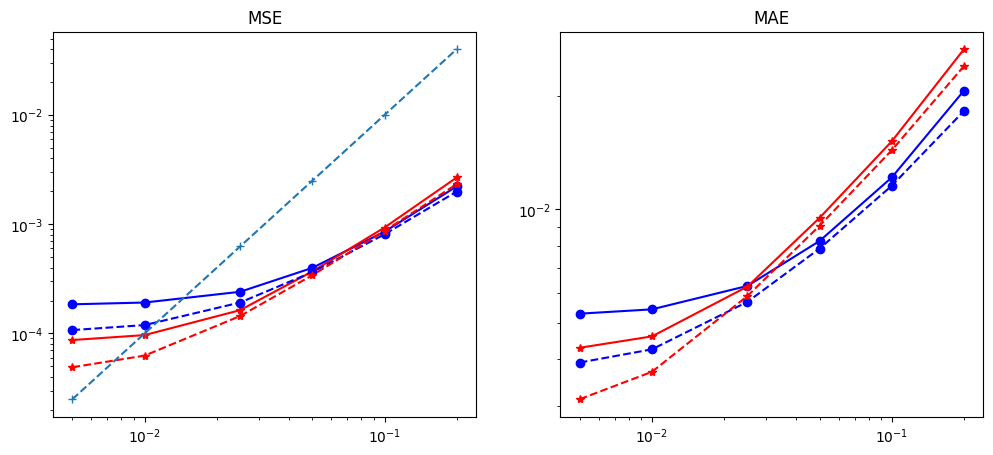

In [40]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(noiseLevels,mseVal,'bo-')
plt.plot(noiseLevels,mseTest,'r*-')
plt.plot(noiseLevels,mseValFull,'bo--')
plt.plot(noiseLevels,mseTestFull,'r*--')
plt.plot(noiseLevels,np.array(noiseLevels)**2,'+--')
plt.yscale('log')
plt.xscale('log')
plt.title('MSE')
plt.subplot(122)
plt.plot(noiseLevels,maeVal,'bo-')
plt.plot(noiseLevels,maeTest,'r*-')
plt.plot(noiseLevels,maeValFull,'bo--')
plt.plot(noiseLevels,maeTestFull,'r*--')
plt.yscale('log')
plt.xscale('log')
plt.title('MAE')

### Results comment:
The network, with the enlarged training dataset trains even better

## Show recon images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


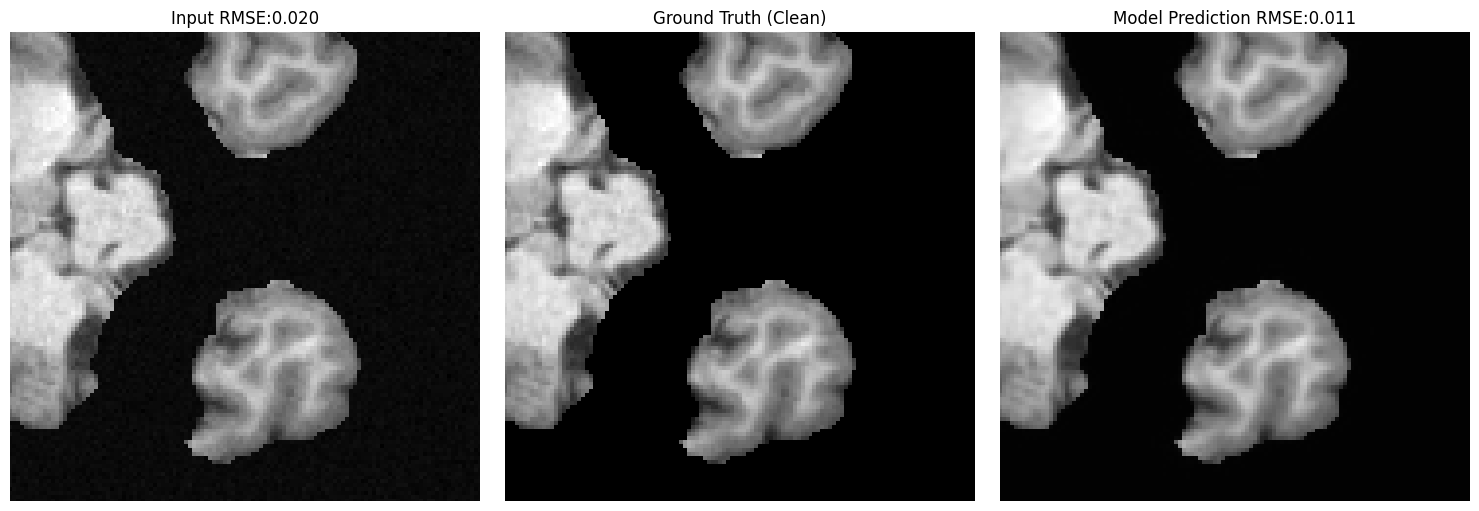

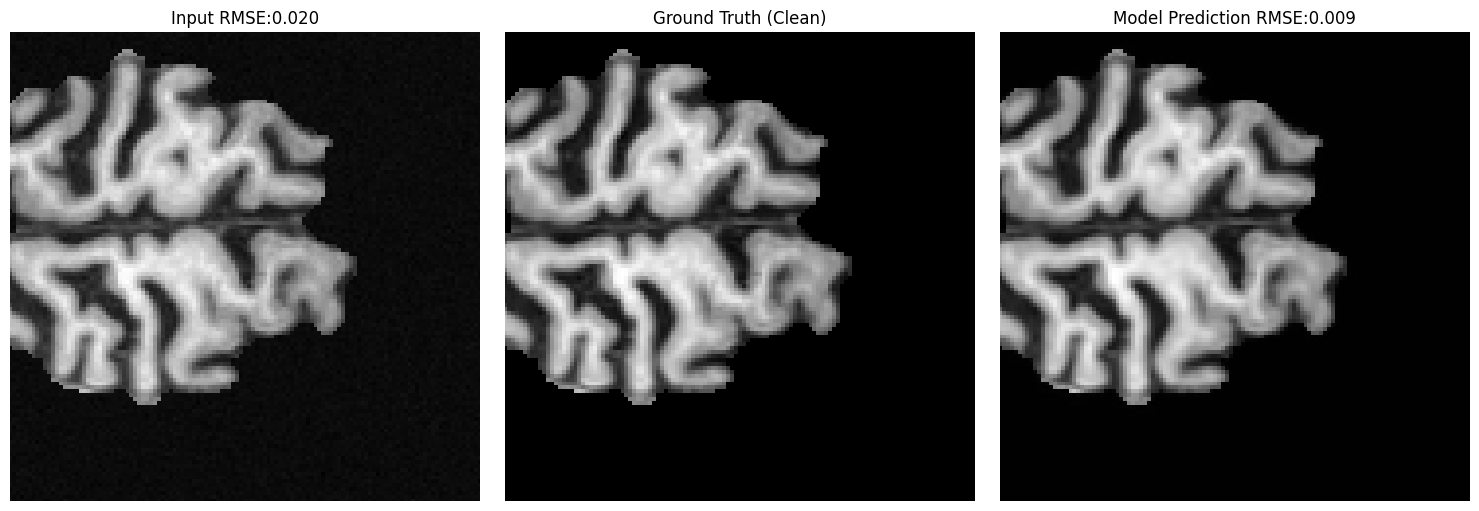

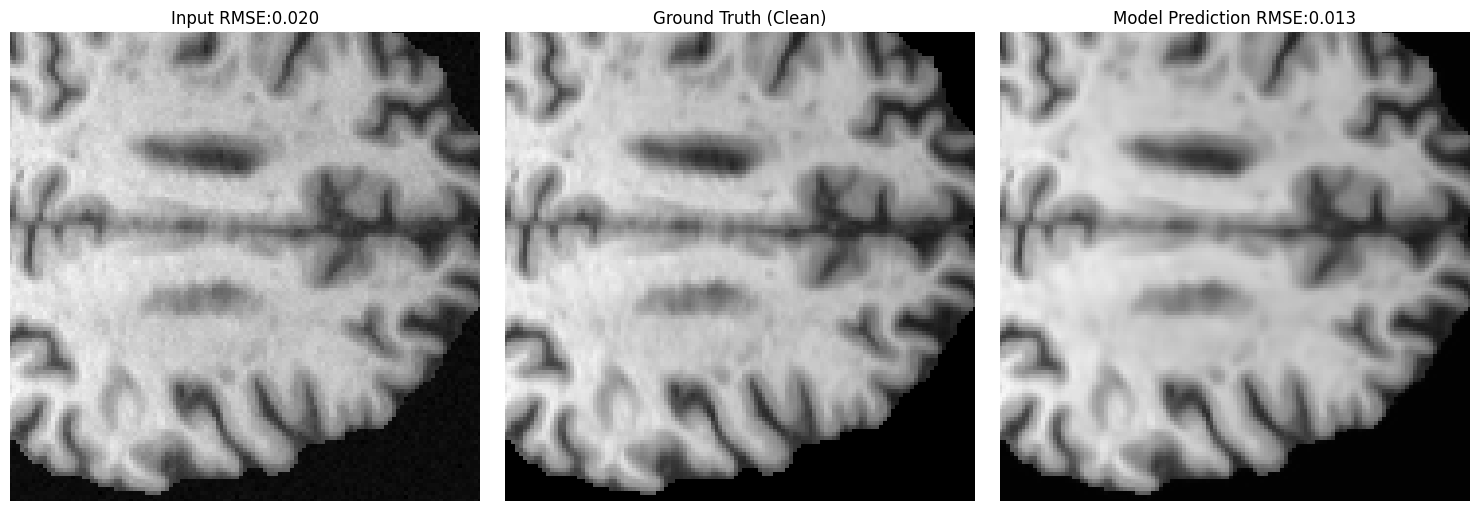

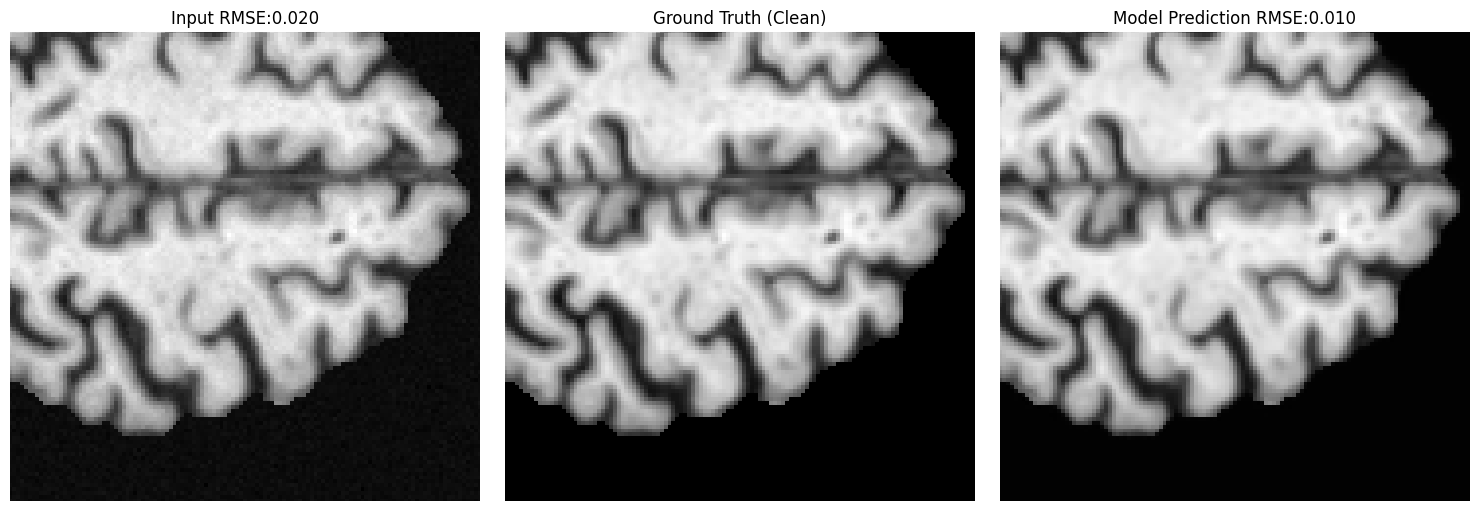

In [44]:
noiseL = 0.02
#idx = np.random.randint(0,data_test.shape[0],4)
outTrue = data_test[idx,:,:,:]
inpB = outTrue+np.random.normal(0,noiseL,outTrue.shape)
    # Facciamo la predizione sul batch
    # .numpy() serve per convertire il tensore in un array visualizzabile
predicted_batch = myModel.predict(inpB)
    
    # Scegliamo la prima immagine del batch per la visualizzazione
for bIdx in range(4):
        
    plt.figure(figsize=(15, 5))
    iNA = inpB[bIdx,:,:,0]
    iClean = outTrue[bIdx,:,:,0]
    iPred = predicted_batch.squeeze()
    iPred = iPred[bIdx,:,:]
    rmseInp = np.sqrt(np.mean((iNA-iClean)**2))
    rmseOut = np.sqrt(np.mean((iPred-iClean)**2))
    # 1. Input Rumoroso (Quello che la rete "vede")
    plt.subplot(1, 3, 1)
    plt.title(f"Input RMSE:{rmseInp:.3f}")
    plt.imshow(iNA, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)
    plt.axis('off')
    
    # 2. Target Pulito (Quello che la rete "dovrebbe" restituire)
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth (Clean)")
    plt.imshow(iClean, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    # 3. Output del Modello (Quello che la rete "ha ricostruito")
    plt.subplot(1, 3, 3)
    plt.title(f"Model Prediction RMSE:{rmseOut:.3f}")
    plt.imshow(iPred, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Same image as function of noise

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


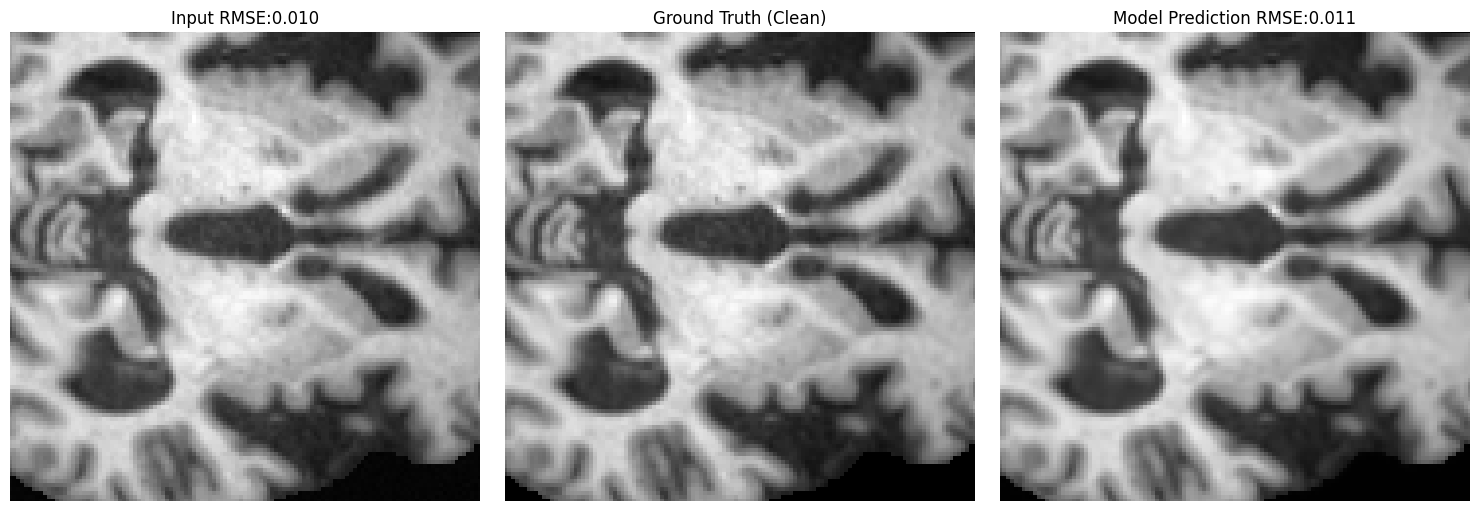

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


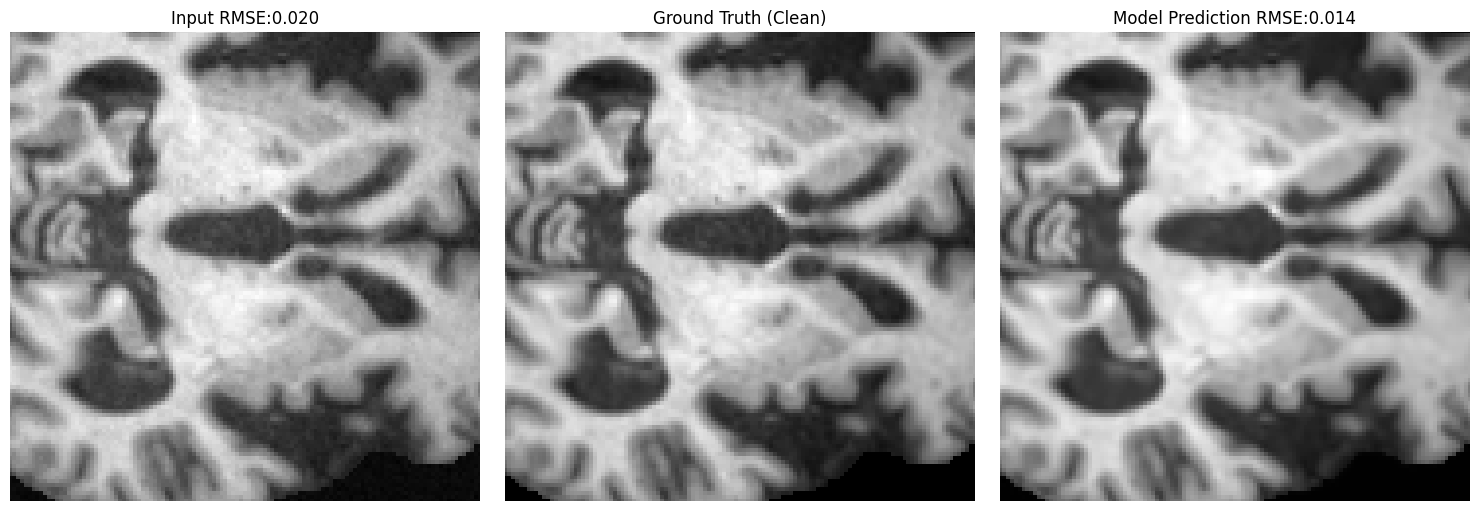

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


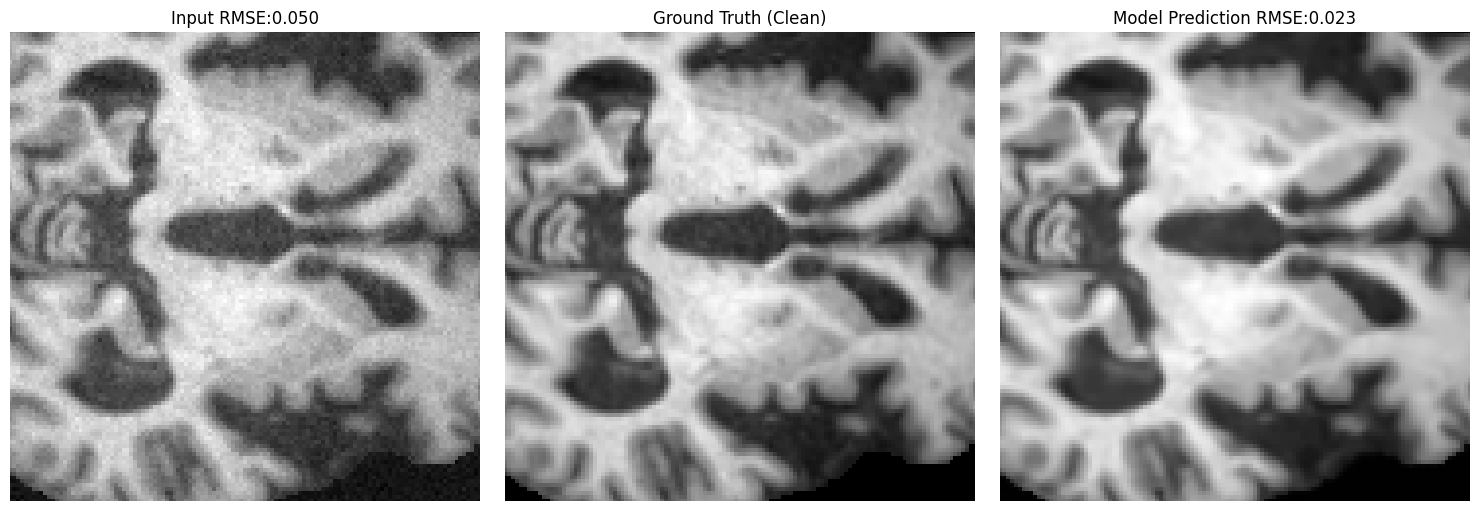

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


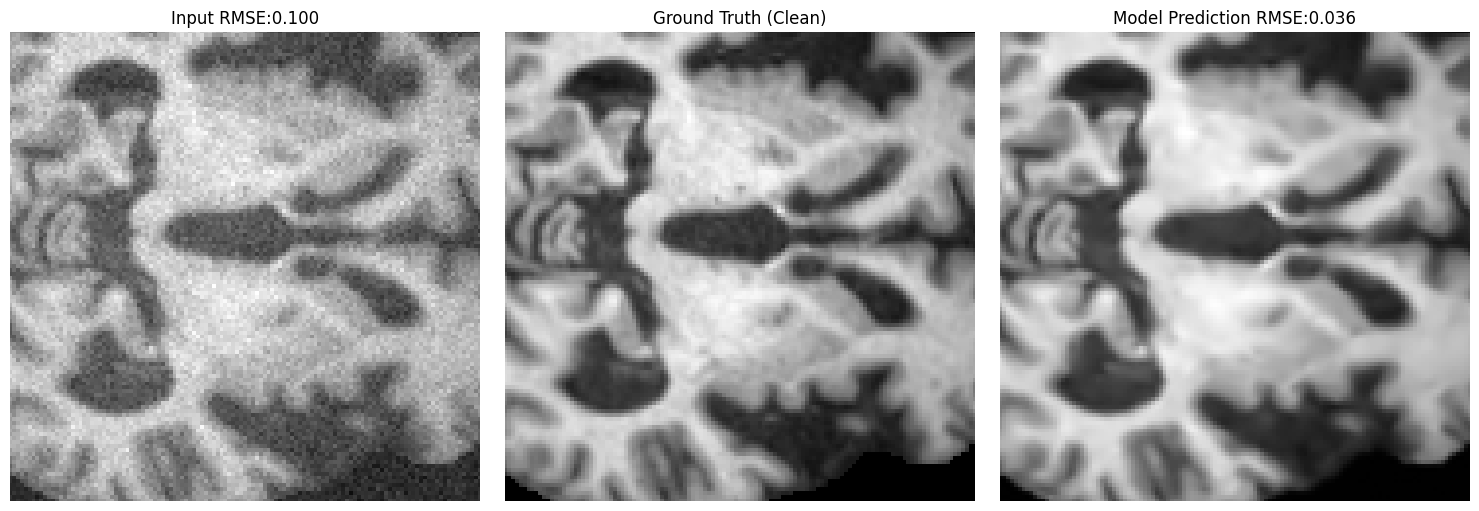

In [92]:

idx = np.random.randint(0,data_test.shape[0],4)
outTrue = data_test[idx,:,:,:]

    
    # Scegliamo la prima immagine del batch per la visualizzazione
bIdx = 3
for noiseL in [0.01,0.02,0.05,0.1]:
    inpB = outTrue+np.random.normal(0,noiseL,outTrue.shape)
    # Facciamo la predizione sul batch
    # .numpy() serve per convertire il tensore in un array visualizzabile
    predicted_batch = myModel.predict(inpB)       
    plt.figure(figsize=(15, 5))
    iNA = inpB[bIdx,:,:,0]
    iClean = outTrue[bIdx,:,:,0]
    iPred = predicted_batch.squeeze()
    iPred = iPred[bIdx,:,:]
    rmseInp = np.sqrt(np.mean((iNA-iClean)**2))
    rmseOut = np.sqrt(np.mean((iPred-iClean)**2))
    # 1. Input Rumoroso (Quello che la rete "vede")
    plt.subplot(1, 3, 1)
    plt.title(f"Input RMSE:{rmseInp:.3f}")
    plt.imshow(iNA, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)
    plt.axis('off')
    
    # 2. Target Pulito (Quello che la rete "dovrebbe" restituire)
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth (Clean)")
    plt.imshow(iClean, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    # 3. Output del Modello (Quello che la rete "ha ricostruito")
    plt.subplot(1, 3, 3)
    plt.title(f"Model Prediction RMSE:{rmseOut:.3f}")
    plt.imshow(iPred, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Compare with a skimage algorithm

In [293]:
from skimage.restoration import denoise_tv_chambolle

In [59]:
noiseLevels = [0.005,0.01,0.025,0.05,0.1,0.2]
betaL = [0.02,0.05,0.1,0.2]
tempD = data_test[:10,:,:,0]
rmseV = np.zeros((len(noiseLevels),len(betaL),10))
for noiseIdx,noise in enumerate(noiseLevels):
    iNoise = tempD+np.random.normal(0,noise,tempD.shape)
    for betaIdx,beta in enumerate(betaL):
        for iIdx in range(tempD.shape[0]):
            iIn = iNoise[iIdx,:,:]
            iOut = denoise_tv_chambolle(iIn,weight=beta)
            rmseV[noiseIdx,betaIdx,iIdx]=np.sqrt(np.mean((iOut-tempD[iIdx,:,:])**2))


Text(0.5, 1.0, 'Beta effectiveness vs noise')

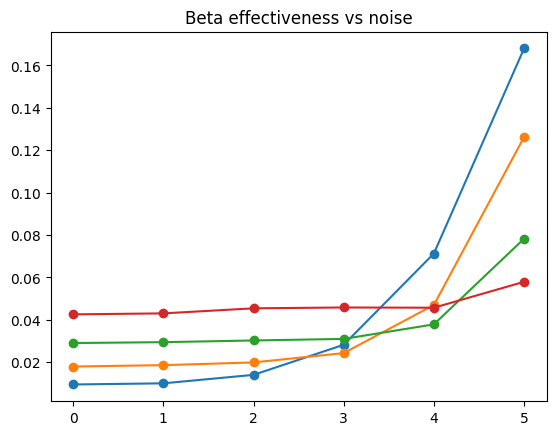

In [79]:
plt.plot(np.mean(rmseV,axis=-1),'o-')
plt.title('Beta effectiveness vs noise')

In [76]:
noiseLevels = [0.005,0.01,0.025,0.05,0.1,0.2]
optBeta = [0.01,0.02,0.02,0.05,0.1,0.2]
mseValTV = np.zeros((len(noiseLevels),))
mseTestTV = np.zeros((len(noiseLevels),))

yValR = yTest[:30,:,:,0]
yTestR = data_test[:30,:,:,0]
for idx,sigmaNoise in enumerate(noiseLevels):
    yNoise = yTestR+np.random.normal(0,sigmaNoise,yTestR.shape)
    mseV = np.array((30,))
    for imIdx in range(30):
        iOut = denoise_tv_chambolle(yNoise[imIdx,:,:],weight=optBeta[idx])
        mseV = (np.mean((iOut-yTestR[imIdx,:,:])**2))
    mseTestTV[idx]=np.mean(mseV)

    noisy_test = yValR+np.random.normal(0,sigmaNoise,yValR.shape)
    for imIdx in range(30):
        iOut = denoise_tv_chambolle(noisy_test[imIdx,:,:],weight=optBeta[idx])
        mseV = np.mean((iOut-yValR[imIdx,:,:])**2)
    mseValTV[idx]=np.mean(mseV)

Text(0.5, 1.0, 'MSE')

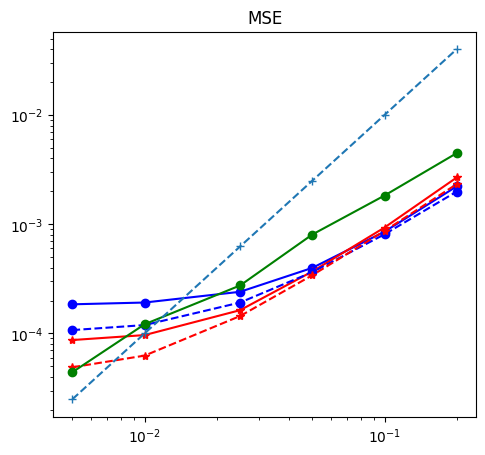

In [77]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(noiseLevels,mseVal,'bo-')
plt.plot(noiseLevels,mseTest,'r*-')
plt.plot(noiseLevels,mseValFull,'bo--')
plt.plot(noiseLevels,mseTestFull,'r*--')
plt.plot(noiseLevels,mseTestTV,'go-')
plt.plot(noiseLevels,np.array(noiseLevels)**2,'+--')
plt.yscale('log')
plt.xscale('log')
plt.title('MSE')


## Plot noise removal gain in db

Text(0, 0.5, 'MSE gain [db]')

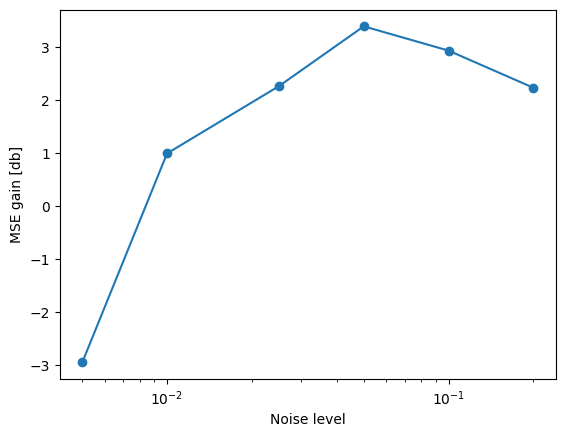

In [78]:
noiseGain = 10*np.log10(mseTestTV/mseTest)

plt.plot(noiseLevels,noiseGain,'o-')
plt.xscale('log')
plt.xlabel('Noise level')
plt.ylabel('MSE gain [db]')


### Results comment
As compared with Total variation denoising, we get almost +3db (half the noise!)

### Results comparison (TV vs CNN)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


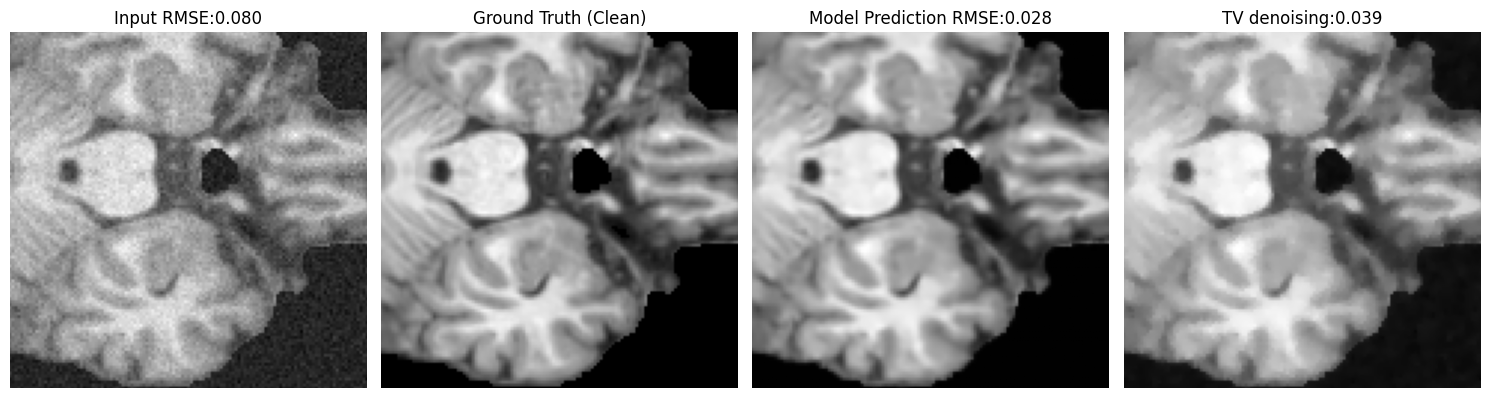

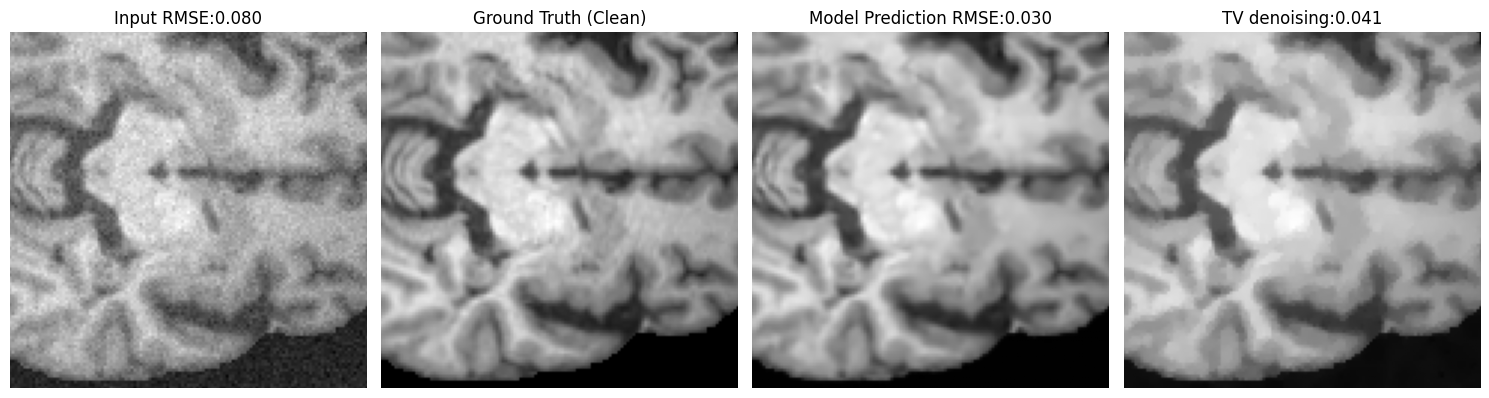

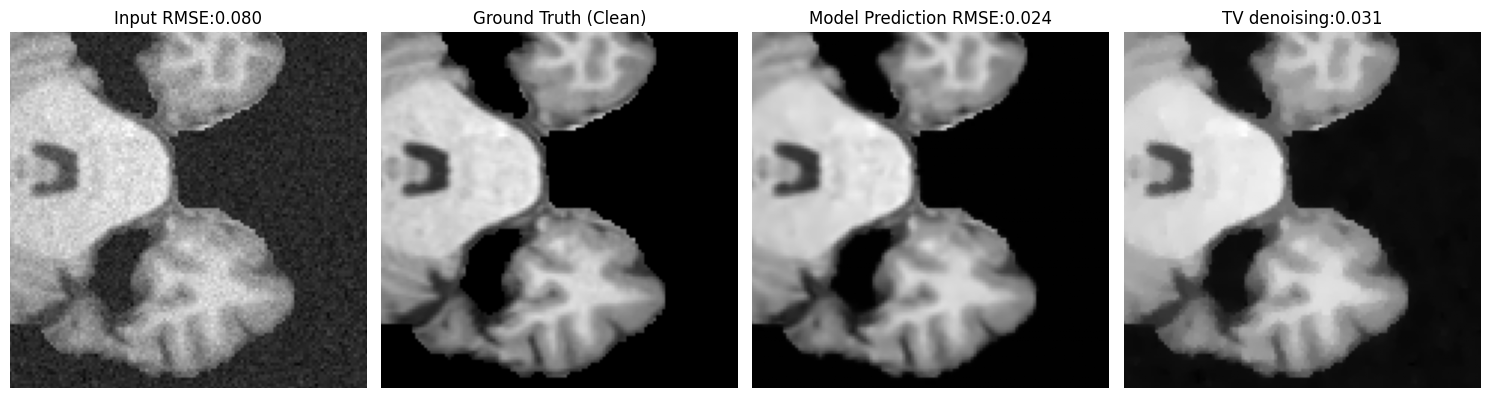

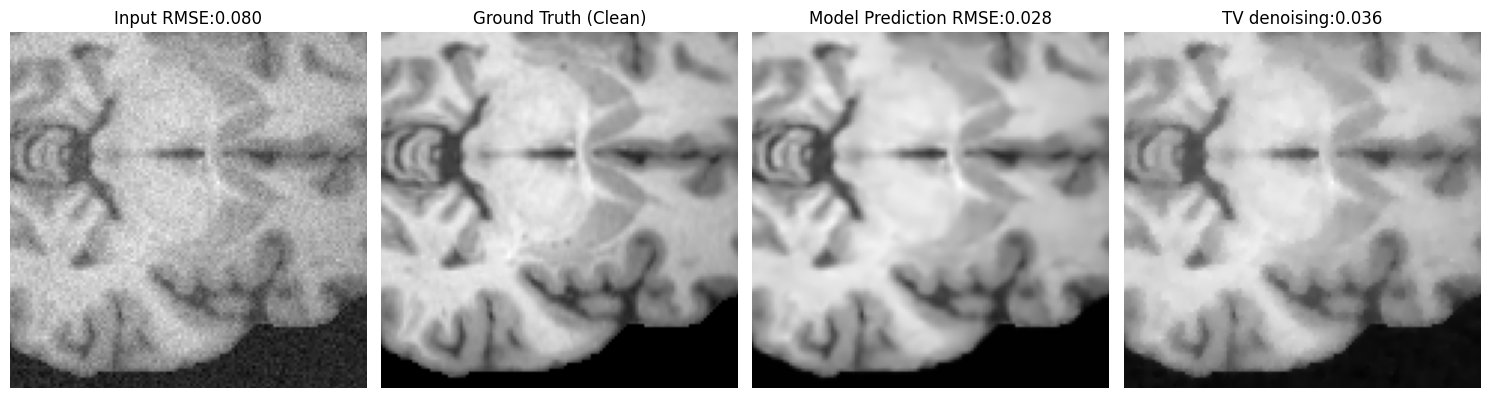

In [121]:
noiseL = 0.08
beta=0.08
idx = np.random.randint(0,data_test.shape[0],4)
outTrue = data_test[idx,:,:,:]
inpB = outTrue+np.random.normal(0,noiseL,outTrue.shape)
    # Facciamo la predizione sul batch
    # .numpy() serve per convertire il tensore in un array visualizzabile
predicted_batch = myModel.predict(inpB)
    
    # Scegliamo la prima immagine del batch per la visualizzazione
for bIdx in range(4):
    plt.figure(figsize=(15, 5))
    iNA = inpB[bIdx,:,:,0]
    iTV = denoise_tv_chambolle(iNA,weight=beta)
    iClean = outTrue[bIdx,:,:,0]
    iPred = predicted_batch.squeeze()
    iPred = iPred[bIdx,:,:]
    rmseInp = np.sqrt(np.mean((iNA-iClean)**2))
    rmseOut = np.sqrt(np.mean((iPred-iClean)**2))
    rmseTV = np.sqrt(np.mean((iTV-iClean)**2))
    # 1. Input Rumoroso (Quello che la rete "vede")
    plt.subplot(1, 4, 1)
    plt.title(f"Input RMSE:{rmseInp:.3f}")
    plt.imshow(iNA, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)
    plt.axis('off')
    
    # 2. Target Pulito (Quello che la rete "dovrebbe" restituire)
    plt.subplot(1, 4, 2)
    plt.title("Ground Truth (Clean)")
    plt.imshow(iClean, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    # 3. Output del Modello (Quello che la rete "ha ricostruito")
    plt.subplot(1, 4, 3)
    plt.title(f"Model Prediction RMSE:{rmseOut:.3f}")
    plt.imshow(iPred, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title(f"TV denoising:{rmseTV:.3f}")
    plt.imshow(iTV, cmap='gray')
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')    
    
    plt.tight_layout()
    plt.show()

# Diffusion model
We have shown that with increasing noise you get the weighted average of all "compatible brains".<br>
Here we will show how you can get a random image out of the input

To do diffusion, the CNN needs to know the input noise level

In [8]:
def unet_4_levels_conditional(input_size=(128, 128, 1), emb_dim=128):
    
    # --- Inputs ---
    x_in = Input(input_size)
    sigma_in = Input((1,))   # noise level input

    # --- Noise embedding ---
    # Standard DDPM-style MLP embedding
    e = layers.Dense(emb_dim, activation='relu')(sigma_in)
    e = layers.Dense(emb_dim, activation='relu')(e)

    # Helper to inject conditioning
    def add_conditional_bias(feature_map, emb):
        # emb: (batch, emb_dim)
        # project to number of channels
        channels = feature_map.shape[-1]
        bias = layers.Dense(channels)(emb)          # (batch, channels)
        bias = layers.Reshape((1,1,channels))(bias) # broadcast
        return feature_map + bias

    # --- Downsampling path ---
    conv1 = Conv2D(32, 3, activation='relu', padding='same')(x_in)
    conv1 = Conv2D(32, 3, activation='relu', padding='same')(conv1)
    conv1 = add_conditional_bias(conv1, e)
    pool1 = MaxPooling2D()(conv1)

    conv2 = Conv2D(64, 3, activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, 3, activation='relu', padding='same')(conv2)
    conv2 = add_conditional_bias(conv2, e)
    pool2 = MaxPooling2D()(conv2)

    conv3 = Conv2D(128, 3, activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, 3, activation='relu', padding='same')(conv3)
    conv3 = add_conditional_bias(conv3, e)
    pool3 = MaxPooling2D()(conv3)

    conv4 = Conv2D(256, 3, activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(conv4)
    conv4 = Conv2D(256, 3, activation='relu', padding='same')(conv4)
    conv4 = add_conditional_bias(conv4, e)

    # --- Upsampling path ---
    up3 = UpSampling2D()(conv4)
    up3 = concatenate([up3, conv3])
    conv5 = Conv2D(128, 3, activation='relu', padding='same')(up3)
    conv5 = Conv2D(128, 3, activation='relu', padding='same')(conv5)
    conv5 = add_conditional_bias(conv5, e)

    up2 = UpSampling2D()(conv5)
    up2 = concatenate([up2, conv2])
    conv6 = Conv2D(64, 3, activation='relu', padding='same')(up2)
    conv6 = Conv2D(64, 3, activation='relu', padding='same')(conv6)
    conv6 = add_conditional_bias(conv6, e)

    up1 = UpSampling2D()(conv6)
    up1 = concatenate([up1, conv1])
    conv7 = Conv2D(32, 3, activation='relu', padding='same')(up1)
    conv7 = Conv2D(32, 3, activation='relu', padding='same')(conv7)
    conv7 = add_conditional_bias(conv7, e)

    outputs = Conv2D(1, 1)(conv7)

    return Model([x_in, sigma_in], outputs)


### New augmentation functions

In [57]:
def add_noise_with_sigma(x):
    # Get the actual batch size dynamically
    batch_size = tf.shape(x)[0]
    
    # Sample a unique sigma for each image in the batch: shape (batch_size, 1, 1, 1)
    # We use extra dims for easy broadcasting with (Batch, H, W, C)
    sigma = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 0.6)

    noise = tf.random.normal(shape=tf.shape(x))
    noisy_x = x + (sigma * noise)
    
    # Flatten sigma to (batch_size, 1) for the model output
    sigma_out = tf.reshape(sigma, [batch_size, 1])
    
    return noisy_x, sigma_out


def apply_intensity_aug(x):
    gain = tf.random.normal(mean=1, stddev=.1, shape=[])
    x = x * gain
    
    gamma = tf.random.normal(mean=1, stddev=.1, shape=[])
    x = tf.pow(x, gamma)
    return x


def get_augmentation_model(img_size=(256, 256)):
    
    clean_input = layers.Input(shape=(*img_size, 1))
    target_input = layers.Input(shape=(*img_size, 1))

    # 1. Concatenate for spatial transforms
    combined = layers.Concatenate(axis=-1)([clean_input, target_input])

    # 2. Spatial + intensity augmentations
    x = layers.RandomFlip("vertical")(combined)
    x = layers.RandomRotation(0.02)(x)
    x = layers.RandomZoom(0.05)(x)
    x = layers.Lambda(apply_intensity_aug)(x)

    # 3. Split back
    aug_input = layers.Lambda(lambda t: t[:, :, :, :1])(x)
    aug_target = layers.Lambda(lambda t: t[:, :, :, 1:])(x)

    # 4. Add noise ONCE and return sigma
    noisy, sigma = layers.Lambda(lambda t: add_noise_with_sigma(t))(aug_input)
    sigma = layers.Lambda(lambda s: tf.reshape(s, (-1, 1)))(sigma)
    return keras.Model(
        inputs=[clean_input, target_input],
        outputs=[noisy, aug_target, sigma]
    )


In [58]:
augModel = get_augmentation_model(img_size=dataV.shape[1:3])

@tf.function
def fast_augment(batch_x):
    noisy, clean, sigma = augModel([batch_x, batch_x], training=True)
    return (noisy, sigma), clean


In [59]:
train_ds = (
    tf.data.Dataset.from_tensor_slices(dataV)
    .shuffle(1000)
    .batch(32)
    .map(fast_augment, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)


In [62]:
test_ds  = (
    tf.data.Dataset.from_tensor_slices(yTest).batch(64)
    .map(fast_augment,num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)

)

In [13]:
myModel = unet_4_levels_conditional(input_size=(192,192,1))


In [14]:
from keras.optimizers import Adam

In [39]:
optim= Adam(learning_rate=1e-4)
myModel.compile(optimizer=optim,loss=tf.keras.losses.MeanSquaredError(),metrics=['mae'])

In [16]:
fitHist = myModel.fit(train_ds,validation_data=test_ds,epochs=1)

I0000 00:00:1778770702.482169  690404 service.cc:153] XLA service 0x7f7ae80497e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778770702.482252  690404 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778770702.637170  690404 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778770703.185531  690404 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778770715.619028  690404 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1145/1145 ━━━━━━━━━━━━━━━━━━━━ 91s 64ms/step - loss: 0.0294 - mae: 0.0725 - val_loss: 0.0058 - val_mae: 0.0377


In [74]:
myModel.optimizer.learning_rate.assign(3e-5)
fitHist = myModel.fit(train_ds,validation_data=test_ds,epochs=200)

Epoch 1/200
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 62s 53ms/step - loss: 0.0017 - mae: 0.0155 - val_loss: 0.0017 - val_mae: 0.0152
Epoch 2/200
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 62s 54ms/step - loss: 0.0017 - mae: 0.0155 - val_loss: 0.0017 - val_mae: 0.0150
Epoch 3/200
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - loss: 0.0017 - mae: 0.0155 - val_loss: 0.0017 - val_mae: 0.0153
Epoch 4/200
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - loss: 0.0018 - mae: 0.0156 - val_loss: 0.0017 - val_mae: 0.0150
Epoch 5/200
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - loss: 0.0017 - mae: 0.0155 - val_loss: 0.0017 - val_mae: 0.0152
Epoch 6/200
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 63s 55ms/step - loss: 0.0018 - mae: 0.0156 - val_loss: 0.0017 - val_mae: 0.0152
Epoch 7/200
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 62s 54ms/step - loss: 0.0018 - mae: 0.0156 - val_loss: 0.0017 - val_mae: 0.0150
Epoch 8/200
1145/1145 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - loss: 0.0018 - mae: 0.0156 - val_loss: 0.0017 - val_mae: 0.0150
Epoch 9/200
1145

In [33]:
myModel.save('/mnt/d/dati_corso/AI_denoise/diff_train.keras')

In [ ]:
#myModel.load_weights('/mnt/d/dati_corso/AI_denoise/diff_train.keras')

## Show denoising of this conditional network

In [340]:
idx[0]=778

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


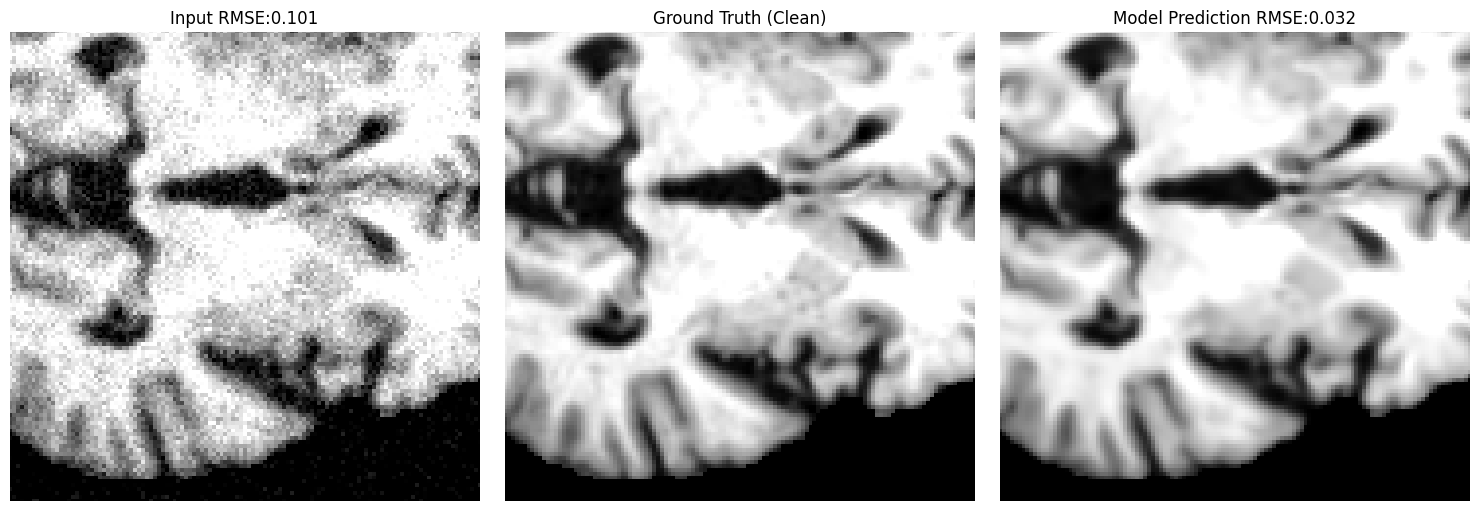

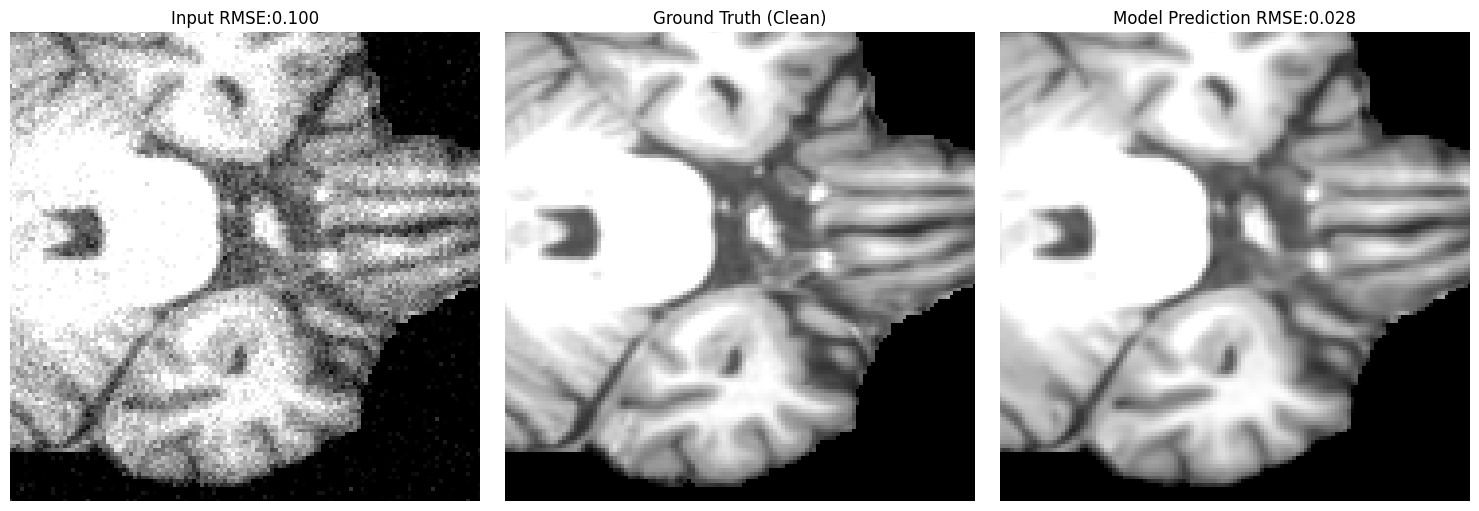

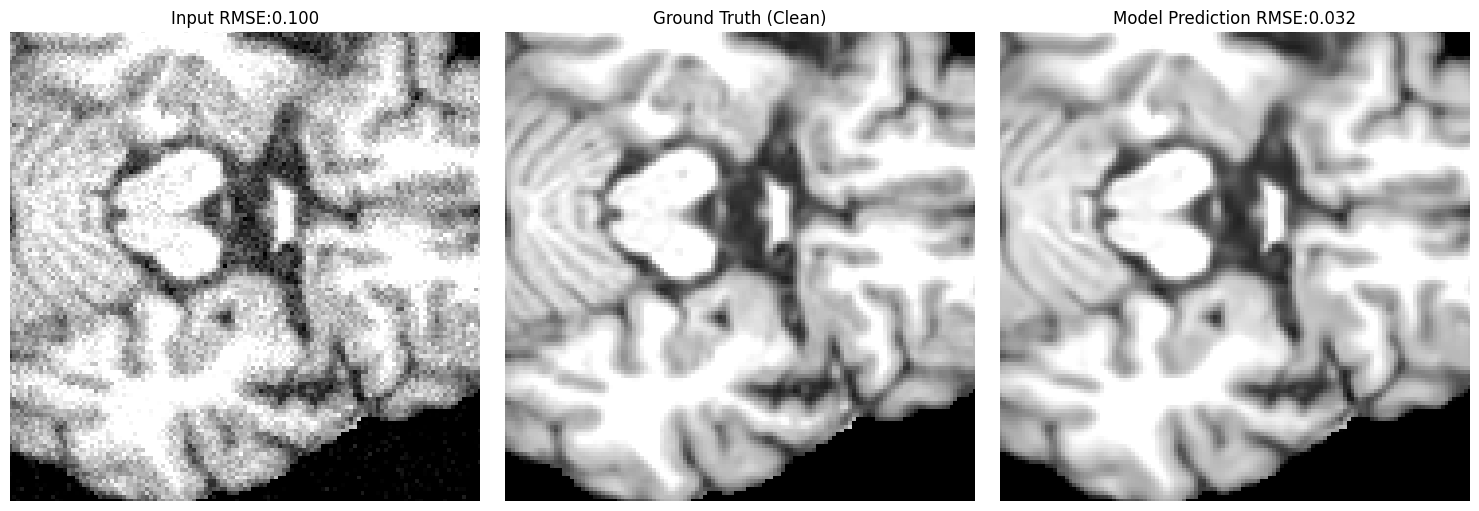

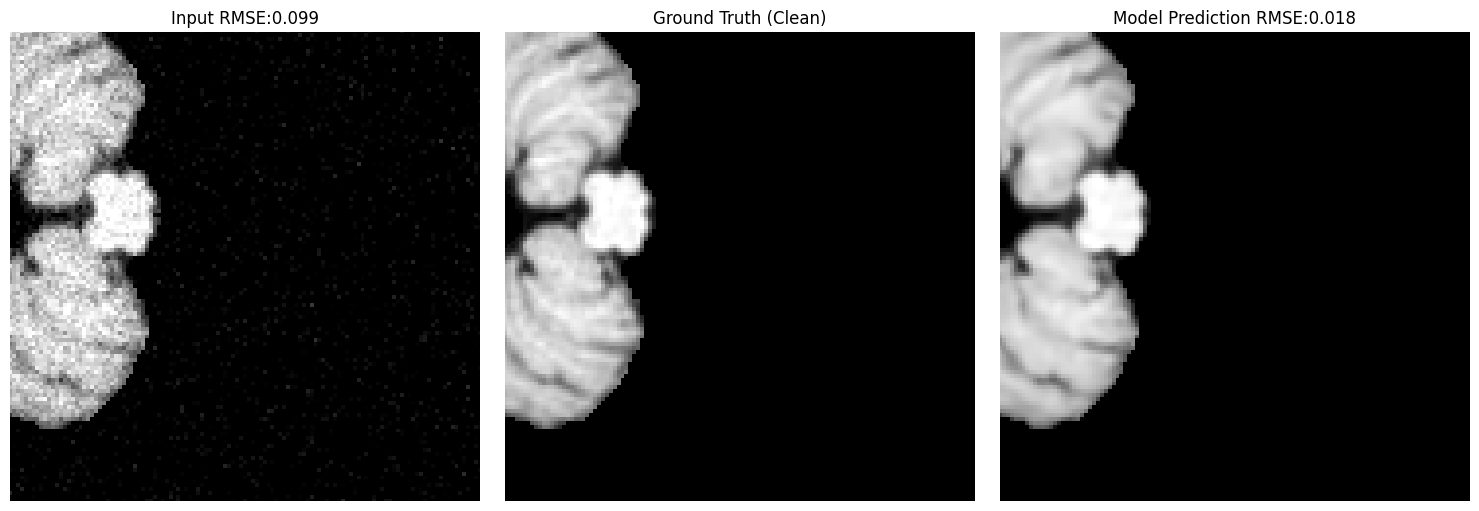

In [341]:
noiseL = 0.1
#idx = np.random.randint(0,data_test.shape[0],4)
outTrue = data_test[idx,:,:,:]
inpB = outTrue+np.random.normal(0,noiseL,outTrue.shape)
    # Facciamo la predizione sul batch
    # .numpy() serve per convertire il tensore in un array visualizzabile
predicted_batch = myModel.predict([inpB,noiseL*np.ones((4,1))])
for bIdx in range(4):
        
    plt.figure(figsize=(15, 5))
    iNA = inpB[bIdx,:,:,0]
    iClean = outTrue[bIdx,:,:,0]
    iPred = predicted_batch.squeeze()
    iPred = iPred[bIdx,:,:]
    rmseInp = np.sqrt(np.mean((iNA-iClean)**2))
    rmseOut = np.sqrt(np.mean((iPred-iClean)**2))
    # 1. Input Rumoroso (Quello che la rete "vede")
    plt.subplot(1, 3, 1)
    plt.title(f"Input RMSE:{rmseInp:.3f}")
    plt.imshow(iNA, cmap='gray',vmin=.1,vmax=1.4)
    plt.xlim(50,170)
    plt.ylim(170,50)
    plt.axis('off')
    
    # 2. Target Pulito (Quello che la rete "dovrebbe" restituire)
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth (Clean)")
    plt.imshow(iClean, cmap='gray',vmin=.1,vmax=1.4)
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    # 3. Output del Modello (Quello che la rete "ha ricostruito")
    plt.subplot(1, 3, 3)
    plt.title(f"Model Prediction RMSE:{rmseOut:.3f}")
    plt.imshow(iPred, cmap='gray',vmin=.1,vmax=1.4)
    plt.xlim(50,170)
    plt.ylim(170,50)    
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Compare with traditional denoising

In [342]:
noiseL = 0.1
outTrue = data_test[778,:,:,0]
noisyI = outTrue+np.random.normal(0,noiseL,outTrue.shape)

### Gaussian

In [330]:
import scipy.ndimage as ndi

In [343]:
sigmaV = [0.66,0.75,0.9,1,1.1,1.3]
mseV = []
for sigma in sigmaV:
    iSm = ndi.gaussian_filter(noisyI,sigma)
    mse = np.sqrt(np.mean((iSm-outTrue)**2))
    mseV.append(mse)

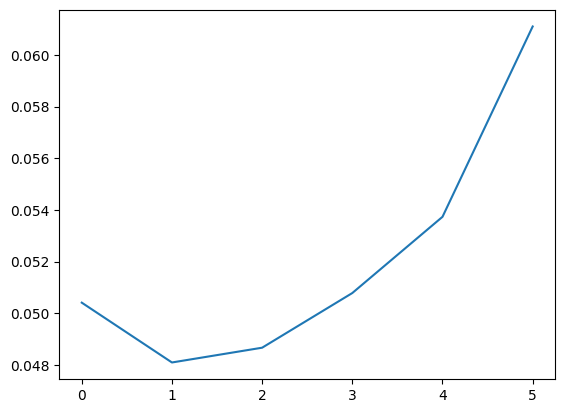

In [344]:
plt.plot(mseV)

### TotVar

In [345]:
betaL = [0.07,0.085,0.1,0.13,0.16,0.2]
mseTV = []

for betaIdx,beta in enumerate(betaL):
        iOut = denoise_tv_chambolle(noisyI,weight=beta)
        mse = np.sqrt(np.mean((iOut-outTrue)**2))
        mseTV.append(mse)


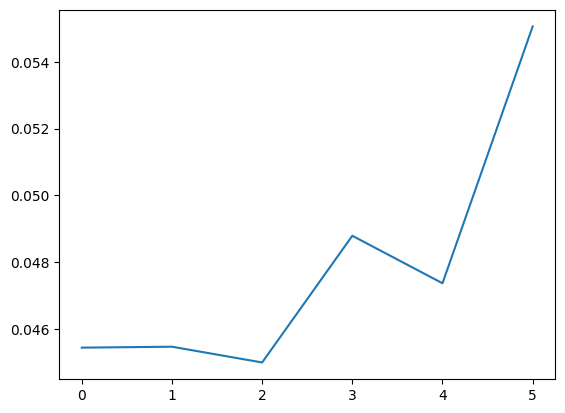

In [346]:
plt.plot(mseTV)

In [347]:
bestTV = denoise_tv_chambolle(noisyI,weight=betaL[2])
bestGauss = ndi.gaussian_filter(noisyI,0.75)

In [335]:
idx

array([ 164, 1940,  336, 2838])

(np.float64(50.0), np.float64(170.0), np.float64(170.0), np.float64(50.0))

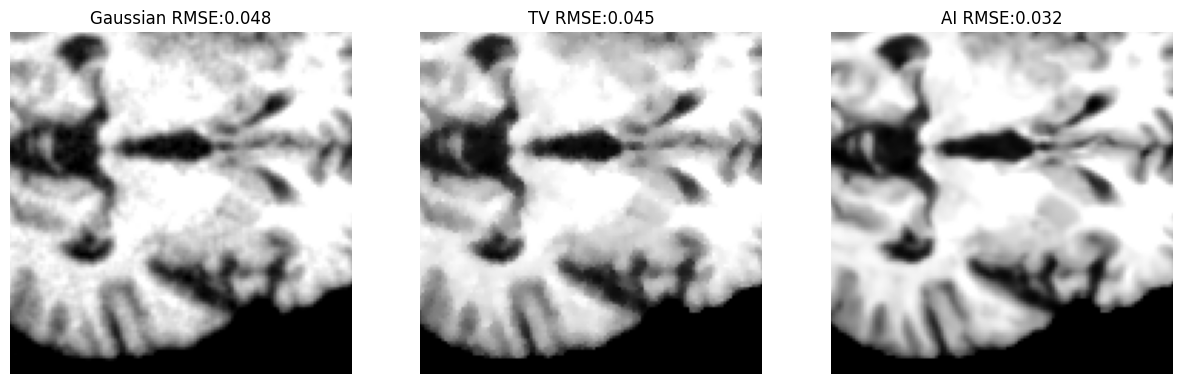

In [351]:
outTrue = data_test[778,:,:,0]
plt.figure(figsize=(15, 5))
rmseGauss = np.sqrt(np.mean((bestGauss-outTrue)**2))
# 1. Input Rumoroso (Quello che la rete "vede")
plt.subplot(1, 3, 1)
plt.title(f"Gaussian RMSE:{rmseGauss:.3f}")
plt.imshow(bestGauss, cmap='gray',vmin=.1,vmax=1.4)
plt.xlim(50,170)
plt.ylim(170,50)
plt.axis('off')
rmseGauss = np.sqrt(np.mean((bestTV-outTrue)**2))
# 1. Input Rumoroso (Quello che la rete "vede")
plt.subplot(1, 3, 2)
plt.title(f"TV RMSE:{rmseGauss:.3f}")
plt.imshow(bestTV, cmap='gray',vmin=.1,vmax=1.4)
plt.xlim(50,170)
plt.ylim(170,50)
plt.axis('off')
rmseGauss = np.sqrt(np.mean((predicted_batch[0,:,:,0]-outTrue)**2))
# 1. Input Rumoroso (Quello che la rete "vede")
plt.subplot(1, 3, 3)
plt.title(f"AI RMSE:{rmseGauss:.3f}")
plt.imshow(predicted_batch[0,:,:,0], cmap='gray',vmin=.1,vmax=1.4)
plt.xlim(50,170)
plt.ylim(170,50)
plt.axis('off')

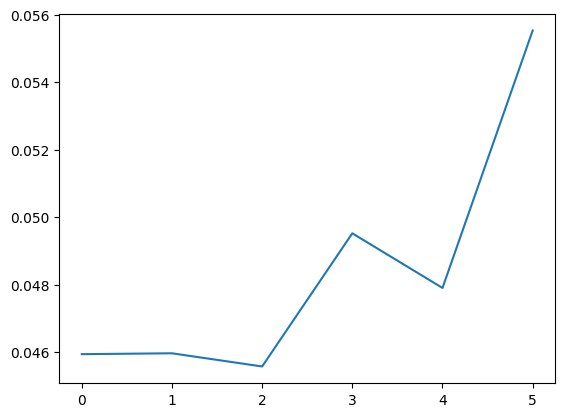

In [301]:
plt.plot(mseTV)

## Diffusion loop

In [ ]:
def sample_diffusion_x0(model, in_imm, n_samples, img_size,t_start, T, alphas, alphas_cumprod, betas, sigmas):
    # 1. Start with pure noise
    x = in_imm
    
    for t in reversed(range(0, t_start + 1)):
        # 2. Prepare inputs for your model
        # Pass the current sigma (the 'noise level') instead of index t
        s_t = np.full((n_samples, 1), sigmas[t], dtype="float32")
        
        # 3. Predict the CLEAN image directly
        # x_0_hat is the model's guess of the denoised digit
        x_0_hat = model.predict([x, s_t], verbose=0)
        
        # 4. Clip the prediction to stay in valid range [-1, 1]
        # This is CRITICAL for x-prediction models to prevent color-drift
        x_0_hat = np.clip(x_0_hat, -1, 1.5)
        
        # 5. Move from x_t to x_{t-1} 
        # We use a weighted average of our current noisy x and the predicted x_0
        if t > 0:
            # Grab constants for the previous step
            a_cp_prev = alphas_cumprod[t-1]
            b_t = betas[t]
            
            # This math "interpolates" between the guess (x_0_hat) and current state (x)
            # to find the mean of the next step
            direction_to_x0 = (np.sqrt(a_cp_prev) * betas[t]) / (1.0 - alphas_cumprod[t])
            direction_to_xt = (np.sqrt(alphas[t]) * (1.0 - a_cp_prev)) / (1.0 - alphas_cumprod[t])
            
            x_mean = direction_to_x0 * x_0_hat + direction_to_xt * x
            
            # 6. Add Langevin noise
            noise = np.random.normal(size=x.shape).astype("float32")
            # Posterior variance calculation
            sigma_step = np.sqrt((1.0 - a_cp_prev) / (1.0 - alphas_cumprod[t]) * b_t)
            x = x_mean + sigma_step * noise
        else:
            x = x_0_hat
            
    return x

In [352]:

# 1. Define a full standard schedule (e.g., 1000 steps)
T_full = 1000 
betas_full = np.linspace(1e-4, 0.02, T_full).astype("float32")
alphas_full = 1.0 - betas_full
alphas_cumprod_full = np.cumprod(alphas_full)
sigmas_full = np.sqrt(1.0 - alphas_cumprod_full)

# 2. Find the index where the schedule matches YOUR input noise (sigma=0.5)
# We look for the t where sigmas_full[t] is closest to 0.5
t_start = np.argmin(np.abs(sigmas_full - 0.58))

print(f"Starting denoising at timestep: {t_start}")

Starting denoising at timestep: 197


In [353]:
dataD = (data_test[11,:,:,:]) 
dataD = dataD+np.random.normal(0,0.58,dataD.shape)
dataD = dataD[None,:,:,:]
dataD = np.repeat(dataD,32,axis=0)
dataD.shape

(32, 192, 192, 1)

In [354]:
denI = sample_diffusion_x0(myModel,dataD,32,192,t_start,T_full,alphas_full,alphas_cumprod_full,betas_full,sigmas_full)

In [356]:
mseD = myModel.predict([dataD,0.58*np.ones((32,1))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


(np.float64(-0.5), np.float64(191.5), np.float64(191.5), np.float64(-0.5))

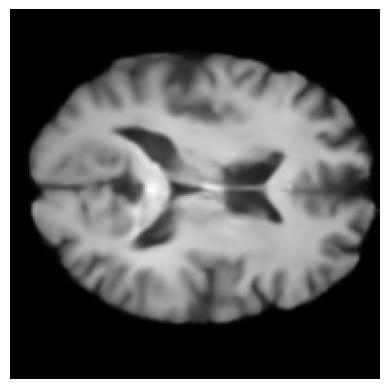

In [357]:
plt.imshow(mseD[0,:,:,0],cmap='gray')
plt.axis('off')

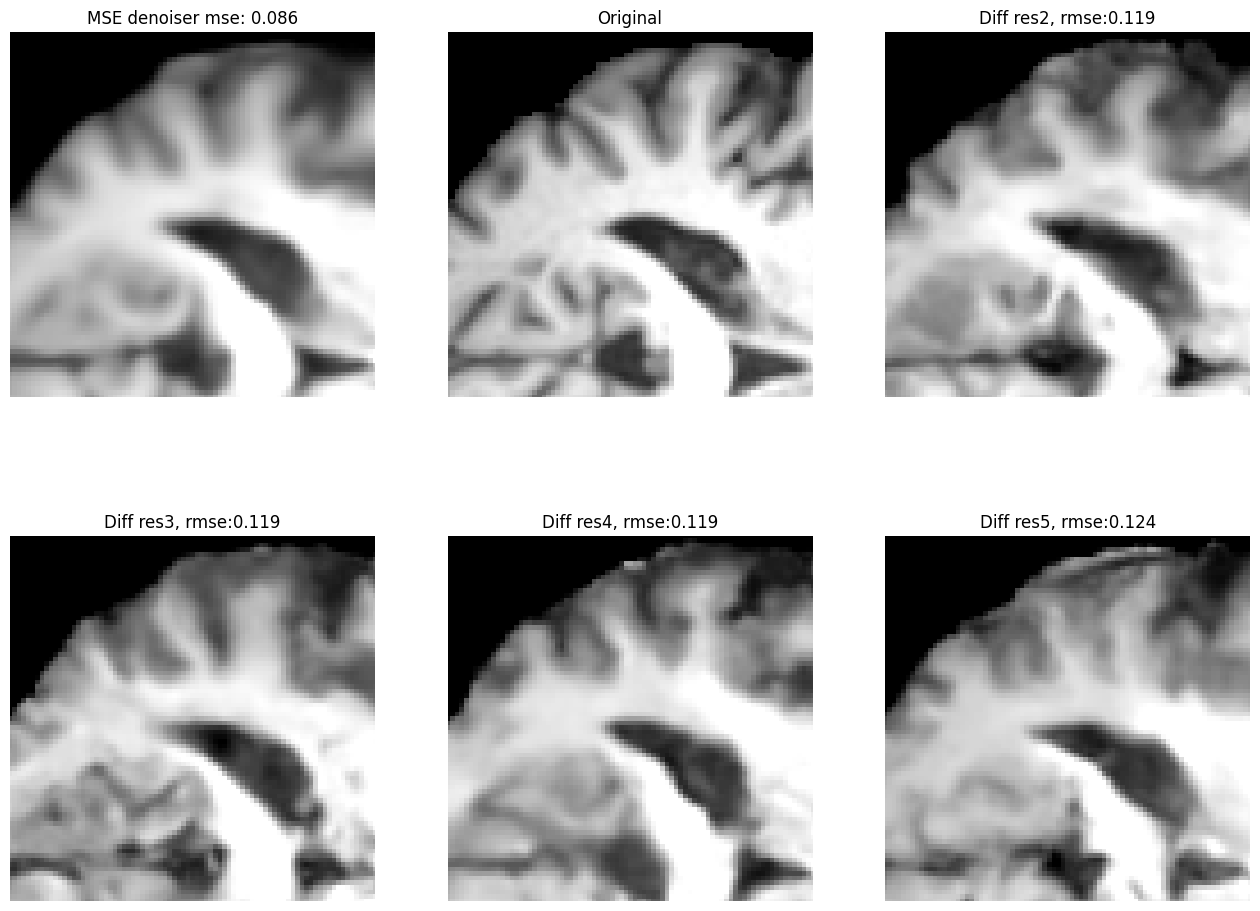

In [368]:
plt.figure(figsize=(16,12))
for i in range(6):
    plt.subplot(2,3,i+1)
    if (i==0):
        plt.imshow(mseD[0,:,:,0],cmap='gray',vmin=.1,vmax=1.4)
        rmse = np.sqrt(np.mean((mseD[0,:,:,0]-data_test[11,:,:,0])**2))
        plt.title(f'MSE denoiser mse: {rmse:.3f}')
    elif (i==1):
        plt.imshow(data_test[11,:,:,0],cmap='gray',vmin=.1,vmax=1.4)
        plt.title('Original')
    else:
        plt.imshow(denI[i,:,:,0],cmap='gray',vmin=.1,vmax=1.4)
        rmse = np.sqrt(np.mean((denI[i,:,:,0]-data_test[11,:,:,0])**2)) 
        plt.title(f'Diff res{i}, rmse:{rmse:.3f}')
       # plt.contour(data_test[11,:,:,0],[.8])
    plt.xlim(20,100)
    plt.ylim(100,20)
    plt.axis('off')